In [ ]:
# 🚀 CONFIGURATION & SETUP (Cluster/Local)
import sys
import time

print("=" * 80)
print("🚀 AUTOMATED SETUP FOR MULTI-PROFILE ANALYSIS (CLUSTER/LOCAL VERSION)")
print("=" * 80)
print("\nRequired Steps:")
print("  1️⃣  Cell 3  - Check/Download Llama 3 model (to /scratch/amine/models)")
print("  2️⃣  Cell 5  - Load model into memory (creates 'llm')")
print("  3️⃣  Cell 7  - Load dataset (from ./Dataset/selected_comments.csv)")
print("  4️⃣  Cell 11 - Configure analysis (Sample size & Text column)")
print("\n" + "=" * 80)

# Verify Environment
print("\n🔍 Environment Check:")
try:
    import llama_cpp
    import huggingface_hub
    import pandas as pd
    import numpy as np
    print("  ✅ All required libraries detected.")
except ImportError as e:
    print(f"  ❌ Missing library: {e}")
    print("  ⚠️  Please install requirements: 'mamba install --file requirements.txt'")

# Check Variables (if re-running)
checks = {
    'llm': 'llm' in dir(),
    'df': 'df' in dir(),
    'text_column': 'text_column' in dir()
}

print("\n📊 Current State:")
for var_name, exists in checks.items():
    print(f"  {'✅' if exists else '❌'} {var_name}: {'Loaded' if exists else 'Not loaded'}")

print("\n" + "=" * 80)


🚀 AUTOMATED SETUP FOR MULTI-PROFILE ANALYSIS

This will run the following cells in sequence:
  1️⃣  Cell 1  - Mount Google Drive
  2️⃣  Cell 2  - Install llama-cpp-python
  3️⃣  Cell 3  - Download Llama 3 model (~4.5GB)
  4️⃣  Cell 4  - Load model into memory (creates 'llm')
  5️⃣  Cell 6  - Load dataset
  6️⃣  Cell 10 - Configure analysis (creates 'df_sample' and 'text_column')


⚠️  IMPORTANT LIMITATION:
Unfortunately, Jupyter/Colab does not allow one cell to programmatically
execute other cells. This is a security and architecture limitation.

🔧 WHAT TO DO INSTEAD:
--------------------------------------------------------------------------------
Please run these cells MANUALLY in order:

  📌 Cell 2  - Mount Google Drive
  📌 Cell 3  - Install llama-cpp-python
  📌 Cell 4  - Download Llama 3 model
  📌 Cell 5  - Load model (creates 'llm' variable)
  📌 Cell 7  - Load dataset
  📌 Cell 11 - Configure analysis (creates 'df_sample' and 'text_column')

💡 TIP: In Colab, you can use 'Runtime > R

In [1]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Install llama-cpp-python using a PRE-BUILT wheel (No compilation needed)
# This specific URL contains the version compiled for Colab's CUDA 12 GPU
!pip install llama-cpp-python \
  --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

!pip install huggingface_hub

Mounted at /content/drive
Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu122
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.6/551.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.6 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import hf_hub_download
import os

# --- CONFIGURATION ---
# Use a folder on your Scratch/Work storage (Replace 'amine' if needed, but it should match your user)
model_folder = "/scratch/amine/models" 
repo_id = "MaziyarPanahi/Meta-Llama-3-8B-Instruct-GGUF"
filename = "Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"
model_path = os.path.join(model_folder, filename)

print(f"Target Model Path: {model_path}")

# --- DOWNLOAD (Only if missing) ---
if not os.path.exists(model_path):
    print(f"Model not found at {model_path}. Downloading...")
    os.makedirs(model_folder, exist_ok=True)
    # Using the huggingface hub downloader
    model_path = hf_hub_download(repo_id=repo_id, filename=filename, local_dir=model_folder)
    print("Download complete!")
else:
    print(f"✅ Model found at {model_path}. Ready to load.")


This uses the free Hugging Face download tool (No transformers library involved).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Model saved at: /content/drive/MyDrive/GGUF_Models/Meta-Llama-3-8B-Instruct.Q4_K_M.gguf


**Testing the model**

In [3]:
from llama_cpp import Llama

print("Loading model into RAM...")

# Initialize the model
llm = Llama(
    model_path=model_path,
    n_gpu_layers=-1,      # -1 = Move all layers to GPU (Maximum Speed)
    n_ctx=8192,           # Context window size
    verbose=False         # Set to True if you want to see debug info
)

# Define the prompt (Using Llama 3 specific formatting)
system_message = "You are a helpful assistant."
user_message = "what LLaMA model are you ? is it the best to analyse text and annotate it ?"

# Llama 3 Prompt Format
prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n{system_message}<|eot_id|><|start_header_id|>user<|end_header_id|>\n\n{user_message}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"

print("Generating response...")

# Run Inference
output = llm(
    prompt,
    max_tokens=512,  # How long the answer can be
    stop=["<|eot_id|>"], # Stop generating when the AI finishes
    echo=False       # Don't repeat the prompt in the output
)

# Print the result
print(output['choices'][0]['text'])

Loading model into RAM...
Generating response...
I'm LLaMA-125M, a variant of the LLaMA model developed by Meta AI. I'm a large language model trained on a massive dataset of text from the internet, which enables me to understand and generate human-like language.

As for whether I'm the best model for analyzing text and annotating it, I'd say I'm quite capable, but the "best" model depends on the specific task, dataset, and requirements. Here are some strengths I bring to the table:

1. **Comprehensive understanding**: My training data includes a vast range of topics, styles, and formats, which allows me to recognize and analyze text from various domains and genres.
2. **Contextualized language understanding**: I'm capable of understanding the context in which a piece of text is written, including the relationships between entities, events, and concepts.
3. **Annotating capabilities**: I can perform various annotation tasks, such as:
	* Sentiment analysis: I can identify the emotional 

# Multi-Attribute Comment Analysis

This notebook analyzes comments for multiple attributes:
- **Sentiment** (1-5): Very Negative to Very Positive
- **Respect** (1-2): Disrespectful to Respectful
- **Insult** (1-4): None to Severe
- **Humiliate** (1-3): None to Degrading
- **Status** (1-2): Inferior to Equal
- **Dehumanize** (1-2): No to Yes
- **Violence** (1-2): No to Yes
- **Genocide** (1-2): No to Yes
- **Attack/Defend** (1-4): Defending to Attacking
- **Hate Speech** (0-1): Not hate speech to Hate speech

In [ ]:
# Load dataset from local storage (Cluster Environment)
import pandas as pd
import os

print("🔍 SEARCHING FOR YOUR DATASET")
print("=" * 60)

# Define the local dataset folder
dataset_folder = "./Dataset"  # Relative path to the Dataset folder in your thesis directory
dataset_filename = "selected_comments.csv"
dataset_path = os.path.join(dataset_folder, dataset_filename)

# Check if the file exists
if os.path.exists(dataset_path):
    print(f"\n🎉 FOUND DATASET: {dataset_path}")
    
    # Load the dataset
    df = pd.read_csv(dataset_path)
    print(f"\n✅ Loaded {len(df)} comments")
    print(f"📋 Columns: {list(df.columns)}")
    print("\n📊 First few rows:")
    display(df.head())
    
    # We create df_sample to be compatible with later cells if they use it
    df_sample = df

else:
    print(f"\n❌ DATASET NOT FOUND AT: {dataset_path}")
    print("\n📤 ACTION REQUIRED:")
    print(f"   1. Ensure a folder named '{dataset_folder}' exists in: {os.getcwd()}")
    print(f"   2. Ensure '{dataset_filename}' is inside that folder.")
    print("   3. Come back and re-run this cell")

    # Fallback to search if the specific file isn't found
    print("\n🔍 Searching recursively in current directory for ANY CSV...")
    csv_found = []
    for root, dirs, files in os.walk("."):
        for file in files:
            if file.endswith(".csv"):
                full_path = os.path.join(root, file)
                csv_found.append(full_path)
                print(f"   Found: {full_path}")
    
    if not csv_found:
         raise FileNotFoundError("No CSV files found. Please upload your dataset.")


🔍 SEARCHING FOR YOUR CSV FILE
✅ Drive is mounted at: /content/drive/MyDrive/

� FOLDERS in your Drive root:
------------------------------------------------------------
   📁 1819HAJE/
   📁 266DRH/
   📁 Anime/
   📁 Birthday/
   📁 Camp/
   📁 Colab Notebooks/
   📁 Corrige RL/
   📁 Dataset/
   📁 GGUF_Models/
   📁 Google AI Studio/
   📁 HAJER/
   📁 HuggingFace_Models/
   📁 Notability/
   📁 Notability (1)/
   📁 Notability (2)/
   📁 Notability (3)/
   📁 Osswa/
   📁 Pdf/
   📁 Reportage racism photo/
   📁 Thesis/
   📁 Tryout/
   📁 War9a/
   📁 Week 7/
   📁 Yup/
   📁 allemand/
   📁 atast DAB/
   📁 attestation/
   📁 court metrage/
   📁 intro court metrage/
   📁 prj allmand/
   📁 quarantine/
   📁 sidi bous3id/
   📁 so gehts B2/
   📁 vids/

📄 CSV FILES in Drive root:
------------------------------------------------------------
   � multi_attribute_analysis_20251209_123320.csv (0.05 MB)
      Path: /content/drive/MyDrive/multi_attribute_analysis_20251209_123320.csv

🔍 SEARCHING inside folders for CSV

,comment_id,variance_score,variance_percentile,variance_rank,text,annotator_id,platform,sentiment,respect,insult,...,annotator_education_some_college,annotator_education_college_grad_aa,annotator_education_college_grad_ba,annotator_education_professional_degree,annotator_education_masters,annotator_education_phd,annotator_age,annotator_race,annotator_religion,annotator_sexuality
0,39073,1014.166667,100.0,1.0,Afghanistan will rise. Kashmir will rise. Pale...,5891,2,0.0,2.0,0.0,...,True,False,False,False,False,False,81.0,White,Christian,Straight
1,13076,1014.166667,100.0,1.0,Hence why it is good to blend in with feminist...,5891,0,0.0,0.0,0.0,...,True,False,False,False,False,False,81.0,White,Christian,Straight
2,21293,1014.166667,100.0,1.0,You won't ever catch me fw a nigga twice ✌🏽,5891,2,4.0,4.0,4.0,...,True,False,False,False,False,False,81.0,White,Christian,Straight
3,43507,1014.166667,100.0,1.0,+Sho Ent butthurt queer,5891,3,2.0,4.0,4.0,...,True,False,False,False,False,False,81.0,White,Christian,Straight
4,29154,1014.166667,100.0,1.0,US women's national soccer team co-captain Meg...,5891,2,1.0,2.0,2.0,...,True,False,False,False,False,False,81.0,White,Christian,Straight


***Vanilla Prompting***

In [ ]:
# Define the Multi-Attribute Analyzer class
import re
import time
from datetime import datetime

class MultiAttributeAnalyzer:
    def __init__(self, llm_model):
        self.model = llm_model

        # Prompt template with all attributes including hate speech
        self.prompt_template = '''<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert content moderator analyzing online comments.<|eot_id|><|start_header_id|>user<|end_header_id|>

Analyze this comment and rate it on multiple scales:

Comment: "{text}"

SCORING CRITERIA:
- SENTIMENT (1-5): 1=Very Negative (hate/hostility), 3=Neutral, 5=Very Positive (love/support)
- RESPECT (1-2): 1=Disrespectful/Rude, 2=Respectful/Polite
- INSULT (1-4): 1=None, 2=Mild/Sarcastic, 3=Clear Insult, 4=Severe/Slur
- HUMILIATE (1-3): 1=None, 2=Attempt to embarrass, 3=Degrading/Dehumanizing
- STATUS (1-2): 1=Treats target as inferior, 2=Treats target as equal
- DEHUMANIZE (1-2): 1=No, 2=Yes (animalistic/vermin comparisons)
- VIOLENCE (1-2): 1=No, 2=Yes (calls for physical harm/death)
- GENOCIDE (1-2): 1=No, 2=Yes (calls for mass elimination)
- ATTACK_DEFEND (1-4): 1=Defending group, 2=Defending self, 3=Attacking individual, 4=Attacking group
- HATESPEECH (0-1): 0=Not hate speech, 1=Hate speech (attacks based on identity/protected characteristics)
- CONFIDENCE (0.1-1.0): Analysis confidence

RESPOND WITH ONLY NUMBERS IN THIS FORMAT:
SENTIMENT [number]
RESPECT [number]
INSULT [number]
HUMILIATE [number]
STATUS [number]
DEHUMANIZE [number]
VIOLENCE [number]
GENOCIDE [number]
ATTACK_DEFEND [number]
HATESPEECH [number]
CONFIDENCE [number]<|eot_id|><|start_header_id|>assistant<|end_header_id|>

'''

    def analyze(self, text):
        """Analyze a comment and extract all attributes"""
        try:
            prompt = self.prompt_template.format(text=text[:500])

            response = self.model(
                prompt,
                max_tokens=150,
                temperature=0.1,
                stop=["<|eot_id|>"]
            )

            output = response['choices'][0]['text'].strip().lower()

            # Parse the output
            results = self._parse_output(output)
            results['raw_output'] = output[:200]
            results['text'] = text[:100]

            return results

        except Exception as e:
            print(f"❌ Error analyzing: {e}")
            return self._fallback_analysis(text)

    def _parse_output(self, output):
        """Parse LLM output to extract numeric values"""
        results = {
            'sentiment': 3.0,
            'respect': 1.5,
            'insult': 1.0,
            'humiliate': 1.0,
            'status': 1.5,
            'dehumanize': 1.0,
            'violence': 1.0,
            'genocide': 1.0,
            'attack_defend': 2.0,
            'hatespeech': 0.0,
            'confidence': 0.7
        }

        # Extract numbers in sequence
        number_sequence = re.findall(r'([0-9]\.?[0-9]*)', output)

        if len(number_sequence) >= 10:
            try:
                sentiment = float(number_sequence[0])
                respect = float(number_sequence[1])
                insult = float(number_sequence[2])
                humiliate = float(number_sequence[3])
                status = float(number_sequence[4])
                dehumanize = float(number_sequence[5])
                violence = float(number_sequence[6])
                genocide = float(number_sequence[7])
                attack_defend = float(number_sequence[8])
                hatespeech = float(number_sequence[9])
                confidence = float(number_sequence[10]) if len(number_sequence) > 10 else 0.7

                # Validate and assign
                if 1.0 <= sentiment <= 5.0:
                    results['sentiment'] = sentiment
                if 1.0 <= respect <= 2.0:
                    results['respect'] = respect
                if 1.0 <= insult <= 4.0:
                    results['insult'] = insult
                if 1.0 <= humiliate <= 3.0:
                    results['humiliate'] = humiliate
                if 1.0 <= status <= 2.0:
                    results['status'] = status
                if 1.0 <= dehumanize <= 2.0:
                    results['dehumanize'] = dehumanize
                if 1.0 <= violence <= 2.0:
                    results['violence'] = violence
                if 1.0 <= genocide <= 2.0:
                    results['genocide'] = genocide
                if 1.0 <= attack_defend <= 4.0:
                    results['attack_defend'] = attack_defend
                if 0.0 <= hatespeech <= 1.0:
                    results['hatespeech'] = hatespeech
                if 0.1 <= confidence <= 1.0:
                    results['confidence'] = confidence

            except (ValueError, IndexError):
                pass

        return results

    def _fallback_analysis(self, text):
        """Fallback analysis using keyword detection"""
        text_lower = text.lower()

        results = {
            'sentiment': 3.0,
            'respect': 2.0,
            'insult': 1.0,
            'humiliate': 1.0,
            'status': 2.0,
            'dehumanize': 1.0,
            'violence': 1.0,
            'genocide': 1.0,
            'attack_defend': 2.0,
            'hatespeech': 0.0,
            'confidence': 0.5,
            'raw_output': 'fallback_analysis',
            'text': text[:100]
        }

        # Check for hate indicators
        hate_words = ['hate', 'kill', 'die', 'murder', 'eliminate', 'destroy']
        slurs = ['slur', 'racist', 'sexist']

        if any(word in text_lower for word in hate_words):
            results['sentiment'] = 1.0
            results['respect'] = 1.0
            results['insult'] = 4.0
            results['attack_defend'] = 4.0
            results['hatespeech'] = 1.0

        if any(word in text_lower for word in slurs):
            results['hatespeech'] = 1.0
            results['insult'] = 4.0

        return results

print("✅ MultiAttributeAnalyzer class defined")

✅ MultiAttributeAnalyzer class defined


In [ ]:
# Initialize the analyzer with the loaded model
analyzer = MultiAttributeAnalyzer(llm)
print("✅ Analyzer initialized and ready!")

# Test on a single comment first
test_text = "This is a test comment to verify the analyzer works."
test_result = analyzer.analyze(test_text)

print("\n🧪 Test Analysis Result:")
for key, value in test_result.items():
    if key not in ['raw_output', 'text']:
        print(f"  {key}: {value}")

✅ Analyzer initialized and ready!

🧪 Test Analysis Result:
  sentiment: 3.0
  respect: 2.0
  insult: 1.0
  humiliate: 1.0
  status: 2.0
  dehumanize: 1.0
  violence: 1.0
  genocide: 1.0
  attack_defend: 1.0
  hatespeech: 0.0
  confidence: 0.9


In [ ]:
# Configure analysis parameters
print("📊 Dataset Analysis Configuration")
print("=" * 50)

# Determine text column
text_columns = ['text', 'comment', 'content', 'message']
text_column = None
for col in text_columns:
    if col in df.columns:
        text_column = col
        break

if not text_column:
    print(f"❌ No text column found. Available columns: {list(df.columns)}")
    print("Please specify the column name manually:")
    text_column = input("Enter column name: ").strip()

print(f"✅ Using text column: '{text_column}'")

# Ask for sample size
total_comments = len(df)
print(f"\n📈 Total comments in dataset: {total_comments}")
print(f"⚠️  Note: Analysis can be slow. Recommended sample size: 50-200")

sample_size_input = input(f"Enter sample size (or 'all' for full dataset): ").strip()

if sample_size_input.lower() in ['all', 'a']:
    sample_size = total_comments
    df_sample = df
else:
    sample_size = int(sample_size_input)
    if sample_size < total_comments:
        df_sample = df.sample(n=sample_size, random_state=42)
    else:
        df_sample = df
        sample_size = total_comments

print(f"\n🎯 Will analyze {len(df_sample)} comments")
print(f"⏱️  Estimated time: {len(df_sample) * 3 / 60:.1f} minutes (approx 3 sec per comment)")

📊 Dataset Analysis Configuration
✅ Using text column: 'text'

📈 Total comments in dataset: 200
⚠️  Note: Analysis can be slow. Recommended sample size: 50-200
Enter sample size (or 'all' for full dataset): 200

🎯 Will analyze 200 comments
⏱️  Estimated time: 10.0 minutes (approx 3 sec per comment)


In [ ]:
# Run the multi-attribute analysis on the dataset
print("🚀 Starting Multi-Attribute Analysis")
print("=" * 60)

results = []
total = len(df_sample)
start_time = time.time()

for i, (idx, row) in enumerate(df_sample.iterrows(), 1):
    try:
        comment_text = str(row[text_column])
        if len(comment_text.strip()) == 0:
            continue

        # Analyze the comment
        result = analyzer.analyze(comment_text)

        # Add metadata
        result['comment_id'] = row.get('comment_id', idx)
        result['index'] = idx

        results.append(result)

        # Progress update every 5 comments
        if i % 5 == 0 or i == total:
            elapsed = time.time() - start_time
            avg_time = elapsed / i
            remaining = (total - i) * avg_time

            avg_sentiment = sum(r['sentiment'] for r in results) / len(results)
            avg_hatespeech = sum(r['hatespeech'] for r in results) / len(results)

            print(f"[{i}/{total}] ({i/total*100:.1f}%) | "
                  f"Avg Sentiment: {avg_sentiment:.2f} | "
                  f"Avg HateSpeech: {avg_hatespeech:.2f} | "
                  f"Time: {elapsed:.1f}s | ETA: {remaining:.1f}s")

        # Small delay to prevent overheating
        time.sleep(0.1)

    except Exception as e:
        print(f"⚠️  Error processing comment {i}: {e}")
        continue

elapsed_total = time.time() - start_time
print(f"\n✅ Analysis complete!")
print(f"📊 Processed {len(results)} comments in {elapsed_total:.1f} seconds")
print(f"⏱️  Average: {elapsed_total/len(results):.2f} seconds per comment")

🚀 Starting Multi-Attribute Analysis
[5/200] (2.5%) | Avg Sentiment: 2.60 | Avg HateSpeech: 0.60 | Time: 16.5s | ETA: 643.2s
[10/200] (5.0%) | Avg Sentiment: 2.30 | Avg HateSpeech: 0.60 | Time: 32.1s | ETA: 609.0s
[15/200] (7.5%) | Avg Sentiment: 2.40 | Avg HateSpeech: 0.53 | Time: 49.7s | ETA: 612.7s
[20/200] (10.0%) | Avg Sentiment: 2.05 | Avg HateSpeech: 0.55 | Time: 66.7s | ETA: 599.9s
[25/200] (12.5%) | Avg Sentiment: 1.96 | Avg HateSpeech: 0.56 | Time: 81.4s | ETA: 569.5s
[30/200] (15.0%) | Avg Sentiment: 1.90 | Avg HateSpeech: 0.60 | Time: 98.1s | ETA: 555.8s
[35/200] (17.5%) | Avg Sentiment: 1.77 | Avg HateSpeech: 0.60 | Time: 114.9s | ETA: 541.8s
[40/200] (20.0%) | Avg Sentiment: 1.98 | Avg HateSpeech: 0.53 | Time: 127.7s | ETA: 510.9s
[45/200] (22.5%) | Avg Sentiment: 1.98 | Avg HateSpeech: 0.53 | Time: 144.7s | ETA: 498.5s
[50/200] (25.0%) | Avg Sentiment: 1.98 | Avg HateSpeech: 0.56 | Time: 161.6s | ETA: 484.7s
[55/200] (27.5%) | Avg Sentiment: 1.95 | Avg HateSpeech: 0.56 | 

In [ ]:
# Convert results to DataFrame and display summary
results_df = pd.DataFrame(results)

print("\n📊 ANALYSIS SUMMARY")
print("=" * 60)

# Calculate averages
print("\n📈 Attribute Averages:")
print(f"  • Sentiment (1-5): {results_df['sentiment'].mean():.2f}")
print(f"  • Respect (1-2): {results_df['respect'].mean():.2f}")
print(f"  • Insult (1-4): {results_df['insult'].mean():.2f}")
print(f"  • Humiliate (1-3): {results_df['humiliate'].mean():.2f}")
print(f"  • Status (1-2): {results_df['status'].mean():.2f}")
print(f"  • Dehumanize (1-2): {results_df['dehumanize'].mean():.2f}")
print(f"  • Violence (1-2): {results_df['violence'].mean():.2f}")
print(f"  • Genocide (1-2): {results_df['genocide'].mean():.2f}")
print(f"  • Attack-Defend (1-4): {results_df['attack_defend'].mean():.2f}")
print(f"  • Hate Speech (0-1): {results_df['hatespeech'].mean():.2f}")
print(f"  • Confidence: {results_df['confidence'].mean():.2f}")

# Distribution insights
print("\n📊 Key Distributions:")
hate_count = (results_df['hatespeech'] > 0.5).sum()
print(f"  • Hate Speech detected: {hate_count} comments ({hate_count/len(results_df)*100:.1f}%)")

very_negative = (results_df['sentiment'] <= 1.5).sum()
print(f"  • Very negative sentiment: {very_negative} comments ({very_negative/len(results_df)*100:.1f}%)")

high_insult = (results_df['insult'] >= 3.0).sum()
print(f"  • High insult level: {high_insult} comments ({high_insult/len(results_df)*100:.1f}%)")

violence_detected = (results_df['violence'] > 1.5).sum()
print(f"  • Violence detected: {violence_detected} comments ({violence_detected/len(results_df)*100:.1f}%)")

# Display first few results
print("\n📋 Sample Results (first 5):")
display(results_df[['comment_id', 'sentiment', 'respect', 'insult', 'hatespeech', 'confidence', 'text']].head())


📊 ANALYSIS SUMMARY

📈 Attribute Averages:
  • Sentiment (1-5): 1.98
  • Respect (1-2): 1.29
  • Insult (1-4): 2.77
  • Humiliate (1-3): 2.12
  • Status (1-2): 1.31
  • Dehumanize (1-2): 1.14
  • Violence (1-2): 1.23
  • Genocide (1-2): 1.05
  • Attack-Defend (1-4): 2.80
  • Hate Speech (0-1): 0.54
  • Confidence: 0.84

📊 Key Distributions:
  • Hate Speech detected: 107 comments (53.5%)
  • Very negative sentiment: 122 comments (61.0%)
  • High insult level: 121 comments (60.5%)
  • Violence detected: 45 comments (22.5%)

📋 Sample Results (first 5):


,comment_id,sentiment,respect,insult,hatespeech,confidence,text
0,39073,5.0,2.0,1.0,0.0,0.8,Afghanistan will rise. Kashmir will rise. Pale...
1,13076,1.0,1.0,2.0,1.0,0.8,Hence why it is good to blend in with feminist...
2,21293,1.0,1.0,4.0,1.0,0.9,You won't ever catch me fw a nigga twice ✌🏽
3,43507,1.0,1.0,3.0,1.0,0.8,+Sho Ent butthurt queer
4,29154,5.0,2.0,1.0,0.0,0.9,US women's national soccer team co-captain Meg...


In [ ]:
from google.colab import files
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"multi_attribute_analysis_{timestamp}.csv"

# Save directly to Google Drive
drive_path = f"/content/drive/MyDrive/Dataset/{output_filename}"
results_df.to_csv(drive_path, index=False)
print(f"💾 Results saved to Google Drive: {drive_path}")
print(f"📂 File: {output_filename}")
print(f"📊 Total comments analyzed: {len(results_df)}")

# Also download to your computer
#print("\n⬇️  Downloading results file to your computer...")
#results_df.to_csv(output_filename, index=False)
#files.download(output_filename)

print(f"\n✅ Analysis complete!")
print(f"   • Saved to Drive: {drive_path}")
#print(f"   • Downloaded to: Downloads/{output_filename}")

NameError: name 'results_df' is not defined

## Evaluate LLM Performance vs Human Annotations

Compare the LLM's predictions against human annotations from the original dataset

In [ ]:
# Load ground truth (human annotations) and evaluate LLM performance
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error
import json
import numpy as np
import glob

print("📊 EVALUATION: LLM vs Human Annotations")
print("=" * 70)

# 1. Load the most recent LLM predictions CSV
llm_csv_pattern = "/content/drive/MyDrive/Dataset/multi_attribute_analysis_*.csv"
llm_csv_files = sorted(glob.glob(llm_csv_pattern), reverse=True)

if not llm_csv_files:
    print("❌ No LLM prediction files found!")
    print(f"   Looking for: {llm_csv_pattern}")
    raise FileNotFoundError("No LLM prediction CSV found. Run the analysis first!")

llm_csv_path = llm_csv_files[0]
print(f"📂 Loading LLM predictions from: {llm_csv_path}")
llm_df = pd.read_csv(llm_csv_path)
print(f"   ✅ Loaded {len(llm_df)} LLM predictions")

# 2. Load human annotations (ground truth)
human_csv_path = "/content/drive/MyDrive/Dataset/selected_comments.csv"
print(f"\n📂 Loading human annotations from: {human_csv_path}")

if not os.path.exists(human_csv_path):
    print(f"❌ Human annotation file not found: {human_csv_path}")
    print("   Please ensure selected_comments.csv is in /content/drive/MyDrive/Dataset/")
    raise FileNotFoundError(f"Human annotations not found at {human_csv_path}")

human_df = pd.read_csv(human_csv_path)
print(f"   ✅ Loaded {len(human_df)} human annotations")
print(f"   📋 Columns: {list(human_df.columns)}")

# Check if human annotations exist
if 'hatespeech' in human_df.columns:
    print("\n✅ Found ground truth annotations in human dataset")

    # Merge LLM predictions with human annotations
    # Match by comment_id or index
    eval_df = llm_df.copy()

    # Add human annotations
    for idx, row in eval_df.iterrows():
        comment_id = row.get('comment_id', row.get('index'))
        # Find matching comment in human annotations
        human_row = human_df[human_df.index == comment_id] if 'comment_id' not in human_df.columns else human_df[human_df['comment_id'] == comment_id]

        if len(human_row) > 0:
            human_row = human_row.iloc[0]
            # Add human annotations with _human suffix
            for attr in ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                        'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']:
                if attr in human_row:
                    eval_df.at[idx, f'{attr}_human'] = human_row[attr]

    print(f"\n📋 Evaluating {len(eval_df)} comments\n")

    # Calculate correlations
    print("📈 CORRELATIONS (LLM vs Human):")
    print("-" * 70)
    print(f"{'Attribute':<20} {'Correlation':<15} {'Strength'}")
    print("-" * 70)

    correlations = {}
    for attr in ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']:
        if f'{attr}_human' in eval_df.columns:
            llm_vals = eval_df[attr].dropna()
            human_vals = eval_df[f'{attr}_human'].dropna()

            if len(llm_vals) > 0 and len(human_vals) > 0:
                # Align the indices
                common_idx = llm_vals.index.intersection(human_vals.index)
                if len(common_idx) > 0:
                    corr = eval_df.loc[common_idx, attr].corr(eval_df.loc[common_idx, f'{attr}_human'])
                    correlations[attr] = corr

                    if abs(corr) >= 0.7:
                        strength = "🟢 Strong"
                    elif abs(corr) >= 0.4:
                        strength = "🟡 Moderate"
                    elif abs(corr) >= 0.2:
                        strength = "🟠 Weak"
                    else:
                        strength = "🔴 Very Weak"

                    print(f"{attr:<20} {corr:+.4f}          {strength}")

    # Calculate classification metrics for hate speech
    print("\n🎯 HATE SPEECH CLASSIFICATION METRICS:")
    print("-" * 70)

    if 'hatespeech_human' in eval_df.columns:
        # Convert to binary classes (threshold at 0.5)
        llm_classes = (eval_df['hatespeech'] > 0.5).astype(int)
        human_classes = (eval_df['hatespeech_human'] > 0.5).astype(int)

        # Remove NaN
        mask = llm_classes.notna() & human_classes.notna()
        llm_classes = llm_classes[mask]
        human_classes = human_classes[mask]

        if len(llm_classes) > 0:
            accuracy = accuracy_score(human_classes, llm_classes)
            f1_binary = f1_score(human_classes, llm_classes, average='binary', zero_division=0)
            f1_weighted = f1_score(human_classes, llm_classes, average='weighted', zero_division=0)
            mae = mean_absolute_error(eval_df.loc[mask, 'hatespeech_human'],
                                      eval_df.loc[mask, 'hatespeech'])

            print(f"   • Accuracy:  {accuracy:.3f}")
            print(f"   • F1_binary_Score:  {f1_binary:.3f}")
            print(f"   • F1_weighted_Score:  {f1_weighted:.3f}")
            print(f"   • MAE:       {mae:.3f}")

            # Confusion matrix
            from sklearn.metrics import confusion_matrix
            cm = confusion_matrix(human_classes, llm_classes)
            print(f"\n   Confusion Matrix:")
            print(f"                 Predicted: Not HS  |  Predicted: HS")
            print(f"   Actual: Not HS    {cm[0][0]:>6}        |   {cm[0][1]:>6}")
            print(f"   Actual: HS        {cm[1][0]:>6}        |   {cm[1][1]:>6}")

    # Overall summary
    if correlations:
        avg_corr = np.mean(list(correlations.values()))
        print(f"\n📊 OVERALL PERFORMANCE:")
        print(f"   • Average Correlation: {avg_corr:.3f}")
        print(f"   • Performance: {'🟢 Good' if avg_corr >= 0.6 else '🟡 Moderate' if avg_corr >= 0.4 else '🔴 Needs Improvement'}")

    # Save evaluation metrics
    metrics = {
        'correlations': correlations,
        'n_samples': len(eval_df),
        'average_correlation': float(np.mean(list(correlations.values()))) if correlations else 0
    }

    if 'hatespeech_human' in eval_df.columns and len(llm_classes) > 0:
        metrics['hate_speech_classification'] = {
            'accuracy': float(accuracy),
            'f1_binary_score': float(f1_binary),
            'f1_weighted_score': float(f1_weighted),
            'mae': float(mae)
        }

    # Save to Drive
    metrics_filename = f"evaluation_metrics_{timestamp}.json"
    metrics_path = f"/content/drive/MyDrive/Dataset/evaluation_metrics_{timestamp}.json"
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"\n💾 Evaluation metrics saved to: {metrics_path}")

else:
    print("⚠️  No ground truth annotations found in dataset")
    print(f"   Expected file: {human_csv_path}")
    print("   Evaluation requires human annotations with columns like 'sentiment', 'hatespeech', etc.")


📊 EVALUATION: LLM vs Human Annotations
📂 Loading LLM predictions from: /content/drive/MyDrive/Dataset/multi_attribute_analysis_20251209_123421.csv
   ✅ Loaded 200 LLM predictions

📂 Loading human annotations from: /content/drive/MyDrive/Dataset/selected_comments.csv
   ✅ Loaded 200 human annotations
   📋 Columns: ['comment_id', 'variance_score', 'variance_percentile', 'variance_rank', 'text', 'annotator_id', 'platform', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score', 'infitms', 'outfitms', 'annotator_severity', 'std_err', 'annotator_infitms', 'annotator_outfitms', 'hypothesis', 'target_race', 'target_religion', 'target_origin', 'target_gender', 'target_sexuality', 'target_age', 'target_disability', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'an

# Task
Update the evaluation cell `Vex70_6iqegG` to include Mean Absolute Error (MAE) for all numerical attributes (sentiment, respect, insult, humiliate, status, dehumanize, violence, genocide, attack_defend, hatespeech) alongside existing correlation and hate speech classification metrics. Then, add a new code cell to visualize the calculated correlations using a bar plot. Finally, review the updated evaluation metrics and the correlation visualization.

## Update Evaluation Metrics

### Subtask:
Modify the existing evaluation cell to calculate and display Mean Absolute Error (MAE) for all numerical attributes alongside correlation metrics.


**Reasoning**:
The subtask requires modifying the existing evaluation cell to include Mean Absolute Error (MAE) calculations for all numerical attributes alongside correlation metrics. I will update the code in cell `Vex70_6iqegG` to calculate MAE for each attribute and include it in the printed output and the saved metrics.



In [ ]:
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error
import json
import numpy as np
import glob

print("📊 EVALUATION: LLM vs Human Annotations")
print("=" * 70)

# 1. Load the most recent LLM predictions CSV
llm_csv_pattern = "/content/drive/MyDrive/Dataset/multi_attribute_analysis_*.csv"
llm_csv_files = sorted(glob.glob(llm_csv_pattern), reverse=True)

if not llm_csv_files:
    print("❌ No LLM prediction files found!")
    print(f"   Looking for: {llm_csv_pattern}")
    raise FileNotFoundError("No LLM prediction CSV found. Run the analysis first!")

llm_csv_path = llm_csv_files[0]
print(f"📂 Loading LLM predictions from: {llm_csv_path}")
llm_df = pd.read_csv(llm_csv_path)
print(f"   ✅ Loaded {len(llm_df)} LLM predictions")

# 2. Load human annotations (ground truth)
human_csv_path = "/content/drive/MyDrive/Dataset/selected_comments.csv"
print(f"\n📂 Loading human annotations from: {human_csv_path}")

if not os.path.exists(human_csv_path):
    print(f"❌ Human annotation file not found: {human_csv_path}")
    print("   Please ensure selected_comments.csv is in /content/drive/MyDrive/Dataset/")
    raise FileNotFoundError(f"Human annotations not found at {human_csv_path}")

human_df = pd.read_csv(human_csv_path)
print(f"   ✅ Loaded {len(human_df)} human annotations")
print(f"   📋 Columns: {list(human_df.columns)}")

# Check if human annotations exist
if 'hatespeech' in human_df.columns:
    print("\n✅ Found ground truth annotations in human dataset")

    # Merge LLM predictions with human annotations
    # Match by comment_id or index
    eval_df = llm_df.copy()

    # Add human annotations
    for idx, row in eval_df.iterrows():
        comment_id = row.get('comment_id', row.get('index'))
        # Find matching comment in human annotations
        human_row = human_df[human_df.index == comment_id] if 'comment_id' not in human_df.columns else human_df[human_df['comment_id'] == comment_id]

        if len(human_row) > 0:
            human_row = human_row.iloc[0]
            # Add human annotations with _human suffix
            for attr in ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                        'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']:
                if attr in human_row:
                    eval_df.at[idx, f'{attr}_human'] = human_row[attr]

    print(f"\n📋 Evaluating {len(eval_df)} comments\n")

    # Calculate correlations and MAE
    print("📈 CORRELATIONS & MAE (LLM vs Human):")
    print("-" * 70)
    print(f"{'Attribute':<20} {'Correlation':<15} {'MAE':<10} {'Strength'}")
    print("-" * 70)

    correlations = {}
    maes = {} # Initialize dictionary to store MAEs

    for attr in ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']:
        if f'{attr}_human' in eval_df.columns:
            llm_vals = eval_df[attr].dropna()
            human_vals = eval_df[f'{attr}_human'].dropna()

            if len(llm_vals) > 0 and len(human_vals) > 0:
                # Align the indices
                common_idx = llm_vals.index.intersection(human_vals.index)
                if len(common_idx) > 0:
                    corr = eval_df.loc[common_idx, attr].corr(eval_df.loc[common_idx, f'{attr}_human'])
                    mae = mean_absolute_error(eval_df.loc[common_idx, f'{attr}_human'], eval_df.loc[common_idx, attr])

                    correlations[attr] = corr
                    maes[attr] = mae # Store MAE

                    if abs(corr) >= 0.7:
                        strength = "🟢 Strong"
                    elif abs(corr) >= 0.4:
                        strength = "🟡 Moderate"
                    elif abs(corr) >= 0.2:
                        strength = "🟠 Weak"
                    else:
                        strength = "🔴 Very Weak"

                    print(f"{attr:<20} {corr:+.4f}          {mae:.4f}     {strength}")

    # Calculate classification metrics for hate speech
    print("\n🎯 HATE SPEECH CLASSIFICATION METRICS:")
    print("-" * 70)

    if 'hatespeech_human' in eval_df.columns:
        # Convert to binary classes (threshold at 0.5)
        llm_classes = (eval_df['hatespeech'] > 0.5).astype(int)
        human_classes = (eval_df['hatespeech_human'] > 0.5).astype(int)

        # Remove NaN
        mask = llm_classes.notna() & human_classes.notna()
        llm_classes = llm_classes[mask]
        human_classes = human_classes[mask]

        if len(llm_classes) > 0:
            accuracy = accuracy_score(human_classes, llm_classes)
            f1 = f1_score(human_classes, llm_classes, average='binary', zero_division=0)
            mae_hatespeech = mean_absolute_error(eval_df.loc[mask, 'hatespeech_human'],
                                      eval_df.loc[mask, 'hatespeech'])

            print(f"   • Accuracy:  {accuracy:.3f}")
            print(f"   • F1-Score:  {f1:.3f}")
            print(f"   • MAE:       {mae_hatespeech:.3f}")

            # Confusion matrix
            from sklearn.metrics import confusion_matrix
            cm = confusion_matrix(human_classes, llm_classes)
            print(f"\n   Confusion Matrix:")
            print(f"                 Predicted: Not HS  |  Predicted: HS")
            print(f"   Actual: Not HS    {cm[0][0]:>6}        |   {cm[0][1]:>6}")
            print(f"   Actual: HS        {cm[1][0]:>6}        |   {cm[1][1]:>6}")

    # Overall summary
    if correlations:
        avg_corr = np.mean(list(correlations.values()))
        print(f"\n📊 OVERALL PERFORMANCE:")
        print(f"   • Average Correlation: {avg_corr:.3f}")
        print(f"   • Performance: {'🟢 Good' if avg_corr >= 0.6 else '🟡 Moderate' if avg_corr >= 0.4 else '🔴 Needs Improvement'}")

    # Save evaluation metrics
    metrics = {
        'correlations': correlations,
        'mean_absolute_errors': maes, # Add MAEs to metrics
        'n_samples': len(eval_df),
        'average_correlation': float(np.mean(list(correlations.values()))) if correlations else 0
    }

    if 'hatespeech_human' in eval_df.columns and len(llm_classes) > 0:
        metrics['hate_speech_classification'] = {
            'accuracy': float(accuracy),
            'f1_score': float(f1),
            'mae': float(mae_hatespeech)
        }

    # Save to Drive
    metrics_filename = f"evaluation_metrics_{timestamp}.json"
    metrics_path = f"/content/drive/MyDrive/Dataset/evaluation_metrics_{timestamp}.json"
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"\n💾 Evaluation metrics saved to: {metrics_path}")

else:
    print("⚠️  No ground truth annotations found in dataset")
    print(f"   Expected file: {human_csv_path}")
    print("   Evaluation requires human annotations with columns like 'sentiment', 'hatespeech', etc.")


📊 EVALUATION: LLM vs Human Annotations
📂 Loading LLM predictions from: /content/drive/MyDrive/Dataset/multi_attribute_analysis_20251209_123421.csv
   ✅ Loaded 200 LLM predictions

📂 Loading human annotations from: /content/drive/MyDrive/Dataset/selected_comments.csv
   ✅ Loaded 200 human annotations
   📋 Columns: ['comment_id', 'variance_score', 'variance_percentile', 'variance_rank', 'text', 'annotator_id', 'platform', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score', 'infitms', 'outfitms', 'annotator_severity', 'std_err', 'annotator_infitms', 'annotator_outfitms', 'hypothesis', 'target_race', 'target_religion', 'target_origin', 'target_gender', 'target_sexuality', 'target_age', 'target_disability', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'an

📊 VISUALIZING EVALUATION: CORRELATION MATRIX, SCATTER PLOTS & CONFUSION MATRIX
💾 Correlation Matrix saved to: /content/drive/MyDrive/Dataset/Visualizations/correlation_matrix_20251220_155452.png


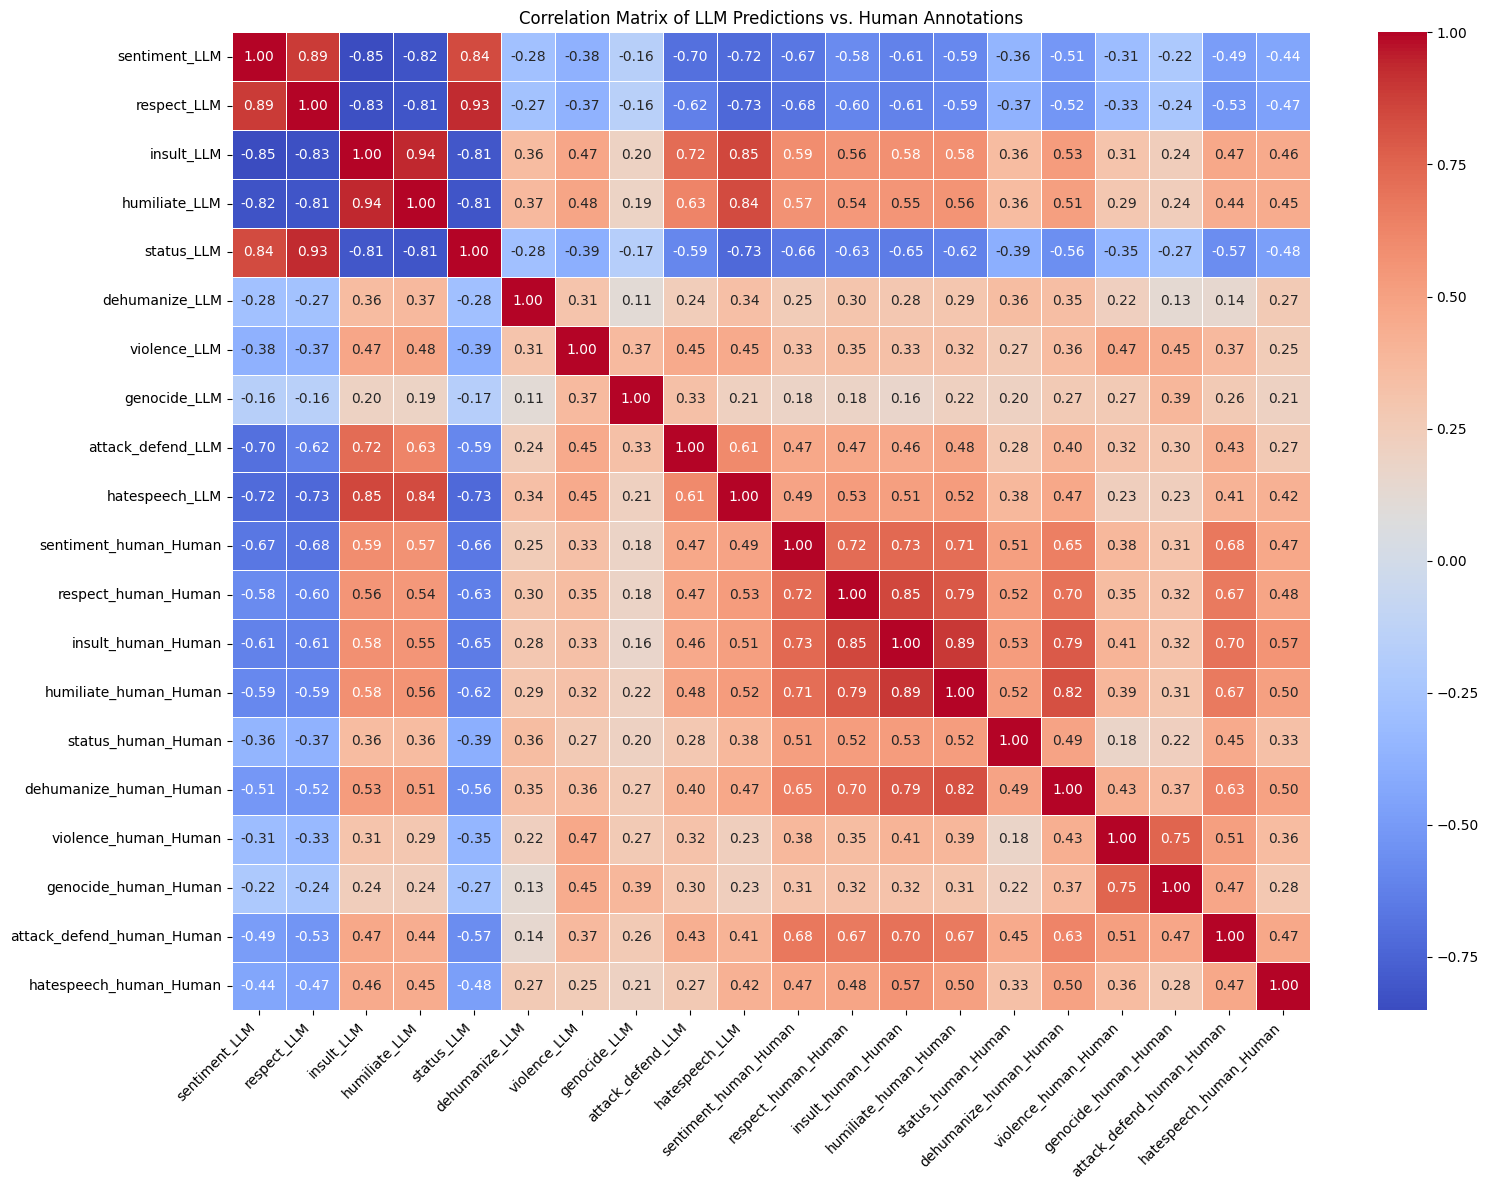


--- Scattered Dot Plots (LLM vs Human) ---

💾 Scatter plot for sentiment saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_sentiment_20251220_155454.png


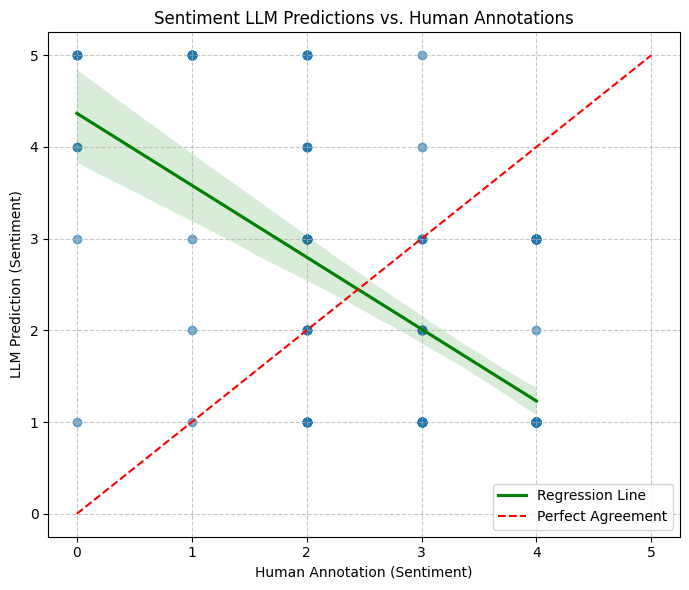

💾 Scatter plot for respect saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_respect_20251220_155455.png


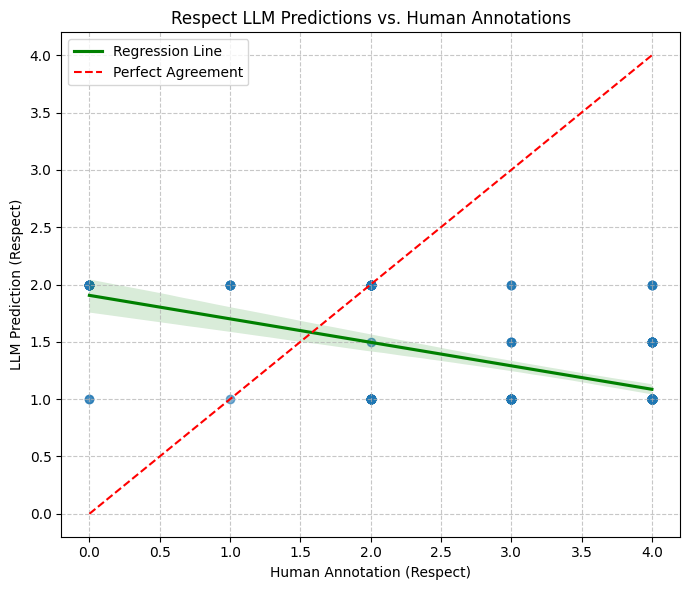

💾 Scatter plot for insult saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_insult_20251220_155455.png


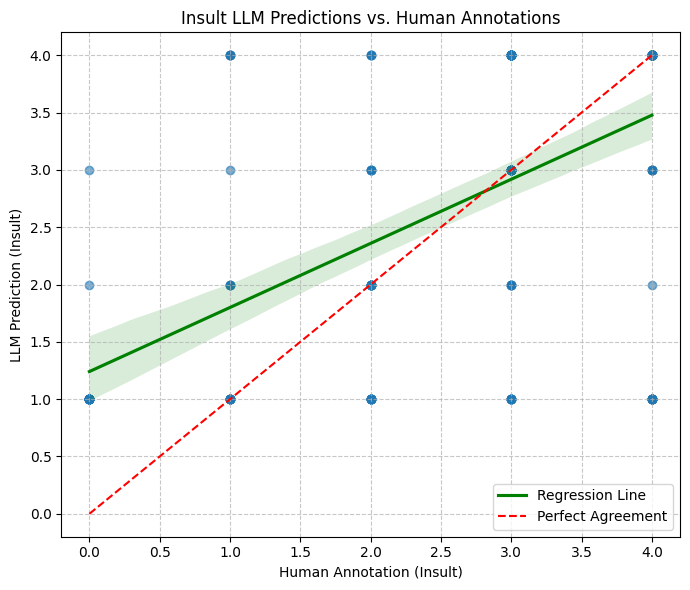

💾 Scatter plot for humiliate saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_humiliate_20251220_155455.png


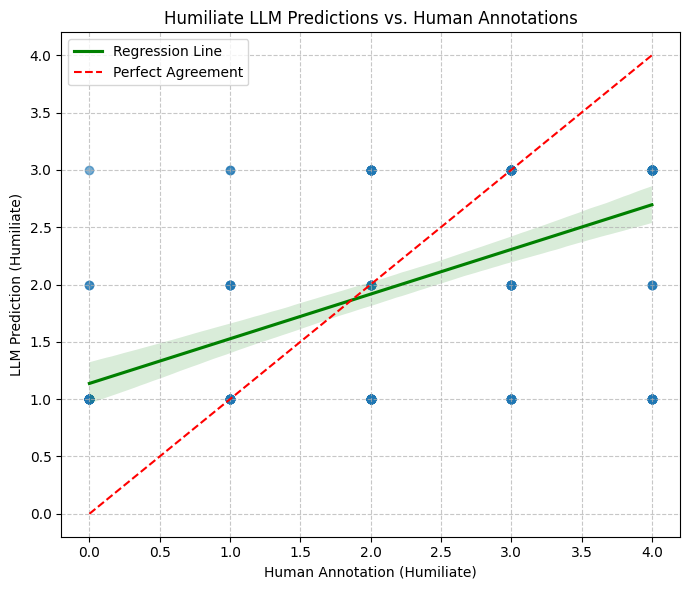

💾 Scatter plot for status saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_status_20251220_155456.png


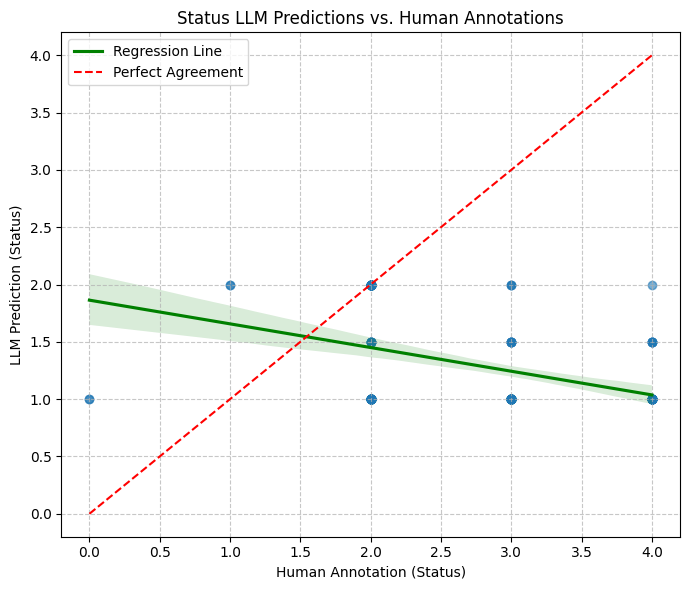

💾 Scatter plot for dehumanize saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_dehumanize_20251220_155456.png


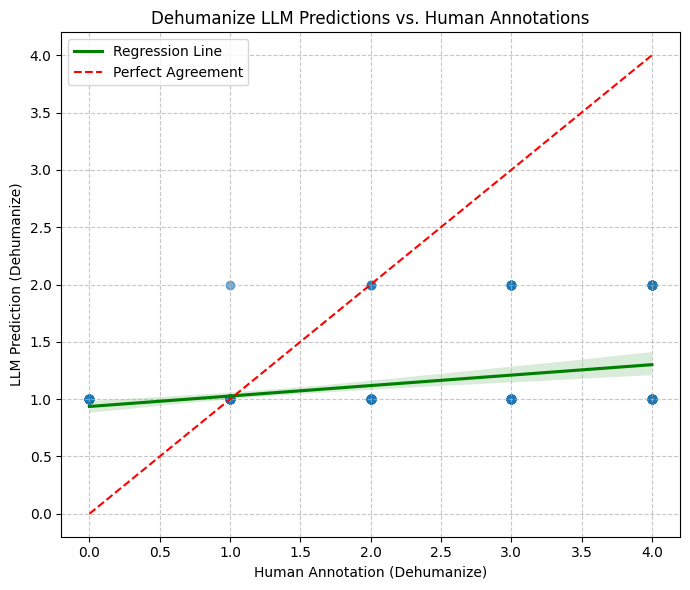

💾 Scatter plot for violence saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_violence_20251220_155457.png


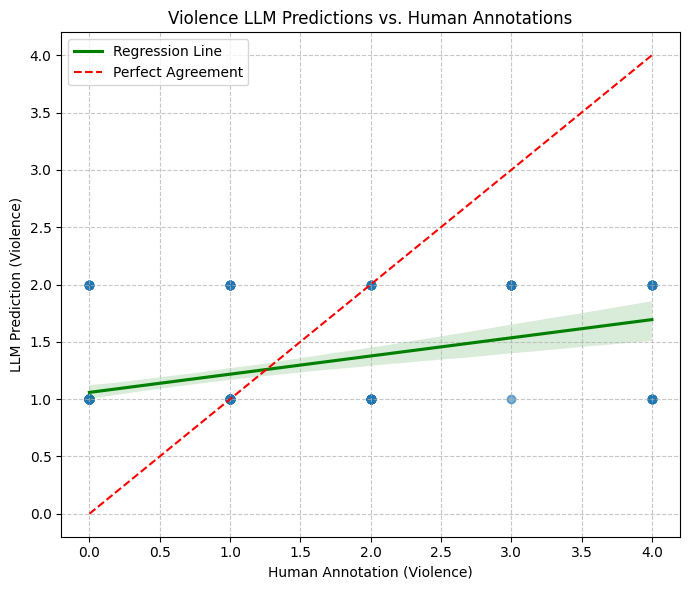

💾 Scatter plot for genocide saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_genocide_20251220_155457.png


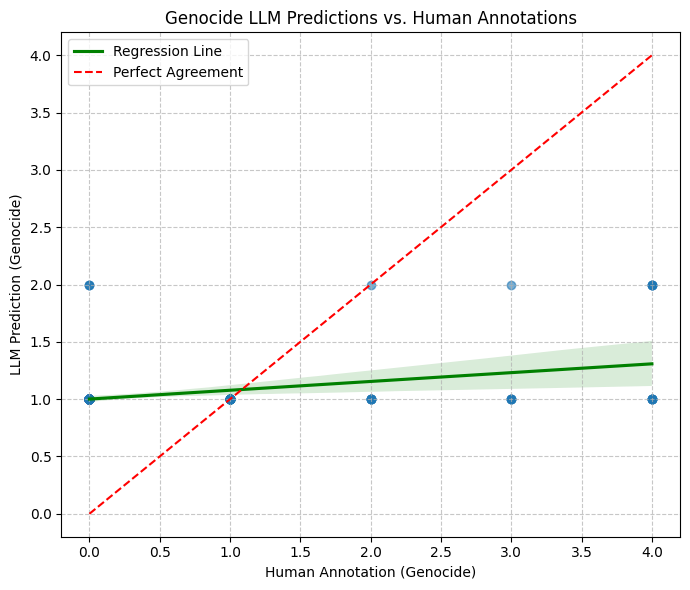

💾 Scatter plot for attack_defend saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_attack_defend_20251220_155458.png


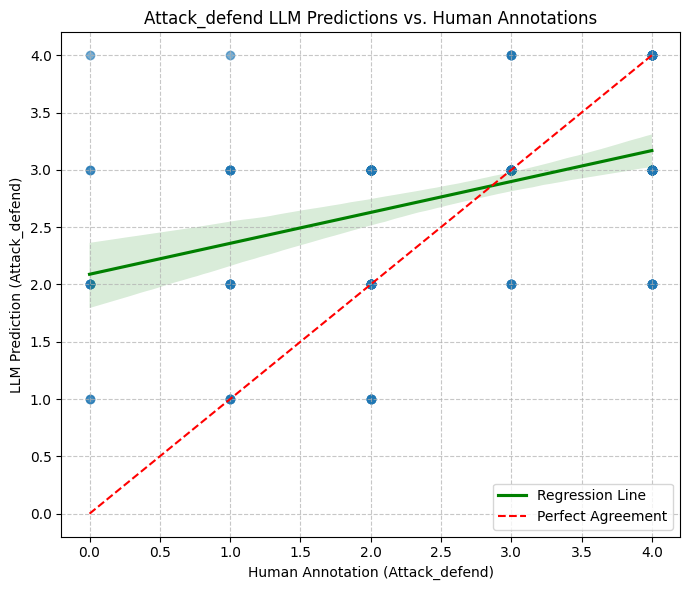

💾 Scatter plot for hatespeech saved to: /content/drive/MyDrive/Dataset/Visualizations/scatter_plot_hatespeech_20251220_155458.png


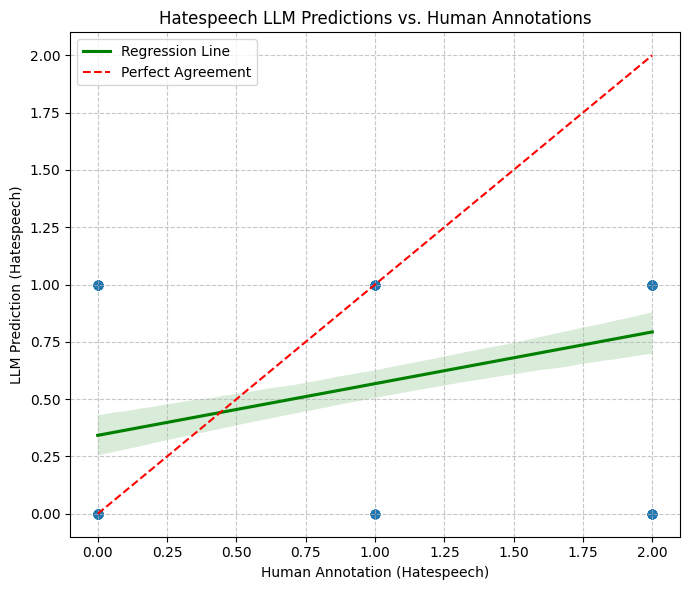


--- Hate Speech Confusion Matrix ---

💾 Confusion Matrix saved to: /content/drive/MyDrive/Dataset/Visualizations/confusion_matrix_20251220_155459.png


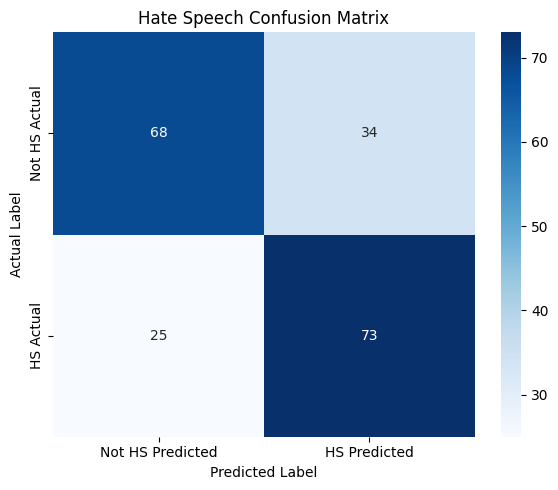


✅ Visualization complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import os
from datetime import datetime

print("📊 VISUALIZING EVALUATION: CORRELATION MATRIX, SCATTER PLOTS & CONFUSION MATRIX")
print("=" * 70)

# Define the folder to save plots
output_folder = "/content/drive/MyDrive/Dataset/Visualizations"
os.makedirs(output_folder, exist_ok=True)

# Ensure eval_df is available from the previous evaluation cell
if 'eval_df' not in locals():
    print("❌ 'eval_df' not found. Please run the evaluation cell (cdce9e89) first.")
else:
    # 1. Prepare data for Correlation Matrix
    # Select only the relevant LLM and human annotation columns
    numeric_cols = ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                    'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']

    llm_cols = [col for col in numeric_cols if col in eval_df.columns]
    human_cols = [f'{col}_human' for col in numeric_cols if f'{col}_human' in eval_df.columns]

    # Create a DataFrame for correlation calculation with only the paired columns
    corr_data = eval_df[llm_cols + human_cols].dropna()

    # Rename columns for better readability in the heatmap
    rename_map = {col: f'{col}_LLM' for col in llm_cols}
    rename_map.update({col: f'{col}_Human' for col in human_cols})
    corr_data = corr_data.rename(columns=rename_map)

    # Calculate Correlation Matrix
    plt.figure(figsize=(16, 12))
    correlation_matrix = corr_data.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of LLM Predictions vs. Human Annotations')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    corr_matrix_filename = os.path.join(output_folder, f"correlation_matrix_{timestamp}.png")
    plt.savefig(corr_matrix_filename)
    print(f"💾 Correlation Matrix saved to: {corr_matrix_filename}")
    plt.show()

    print("\n--- Scattered Dot Plots (LLM vs Human) ---\n")
    # 2. Create Scattered Dot Plots for each attribute
    for attr in numeric_cols:
        llm_col = attr
        human_col = f'{attr}_human'

        if llm_col in eval_df.columns and human_col in eval_df.columns:
            plt.figure(figsize=(7, 6))

            # Plot scatter points and regression line
            sns.regplot(x=human_col, y=llm_col, data=eval_df, scatter_kws={'alpha':0.6}, line_kws={'color':'green', 'label':'Regression Line'})

            # Add a diagonal line for perfect agreement
            min_val = min(eval_df[llm_col].min(), eval_df[human_col].min())
            max_val = max(eval_df[llm_col].max(), eval_df[human_col].max())
            plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Agreement')

            plt.title(f'{attr.capitalize()} LLM Predictions vs. Human Annotations')
            plt.xlabel(f'Human Annotation ({attr.capitalize()})')
            plt.ylabel(f'LLM Prediction ({attr.capitalize()})')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            scatter_filename = os.path.join(output_folder, f"scatter_plot_{attr}_{timestamp}.png")
            plt.savefig(scatter_filename)
            print(f"💾 Scatter plot for {attr} saved to: {scatter_filename}")
            plt.show()
        else:
            print(f"Skipping scatter plot for '{attr}': Missing one or both columns in eval_df.")

    print("\n--- Hate Speech Confusion Matrix ---\n")
    # 3. Hate Speech Confusion Matrix Visualization
    if 'hatespeech_human' in eval_df.columns:
        llm_classes = (eval_df['hatespeech'] > 0.5).astype(int)
        human_classes = (eval_df['hatespeech_human'] > 0.5).astype(int)

        mask = llm_classes.notna() & human_classes.notna()
        llm_classes = llm_classes[mask]
        human_classes = human_classes[mask]

        if len(llm_classes) > 0:
            cm = confusion_matrix(human_classes, llm_classes)
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Not HS Predicted', 'HS Predicted'],
                        yticklabels=['Not HS Actual', 'HS Actual'])
            plt.title('Hate Speech Confusion Matrix')
            plt.ylabel('Actual Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            cm_filename = os.path.join(output_folder, f"confusion_matrix_{timestamp}.png")
            plt.savefig(cm_filename)
            print(f"💾 Confusion Matrix saved to: {cm_filename}")
            plt.show()
        else:
            print("Cannot create confusion matrix: Not enough valid data for hate speech classification.")
    else:
        print("Cannot create confusion matrix: 'hatespeech_human' column not found in eval_df.")


print("\n✅ Visualization complete!")

**Reasoning**:
The next step in the overall task is to visualize the calculated correlations using a bar plot. I will use `matplotlib.pyplot` to create a bar plot of the correlations stored in the `correlations` dictionary.



📊 VISUALIZING CORRELATIONS


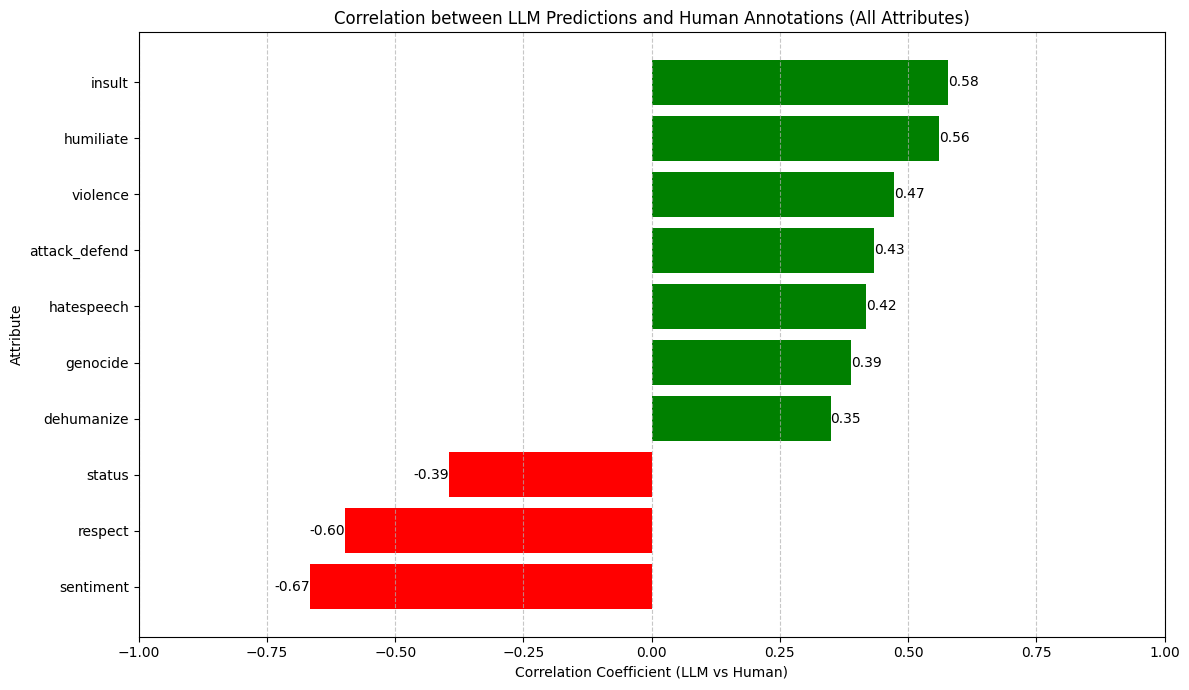

In [ ]:
import matplotlib.pyplot as plt

print("📊 VISUALIZING CORRELATIONS")
print("=" * 60)

if correlations:
    # Prepare data for plotting
    attrs = list(correlations.keys())
    corr_values = list(correlations.values())

    # Sort attributes by correlation value for better visualization
    sorted_indices = np.argsort(corr_values)
    sorted_attrs = [attrs[i] for i in sorted_indices]
    sorted_corr_values = [corr_values[i] for i in sorted_indices]

    # Create the bar plot
    plt.figure(figsize=(12, 7))
    bars = plt.barh(sorted_attrs, sorted_corr_values, color=['green' if c > 0 else 'red' for c in sorted_corr_values])
    plt.xlabel('Correlation Coefficient (LLM vs Human)')
    plt.ylabel('Attribute')
    plt.title('Correlation between LLM Predictions and Human Annotations (All Attributes)')
    plt.xlim([-1.0, 1.0])
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Add correlation values to the bars
    for bar in bars:
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}',
                 va='center', ha='left' if bar.get_width() >= 0 else 'right')

    plt.tight_layout()
    plt.show()
else:
    print("❌ No correlation data available to plot. Run the evaluation cell first!")


## Review the updated evaluation metrics and the correlation visualization

### Subtask:
Analyze the calculated MAE values, correlation coefficients, and the bar plot to summarize the LLM's performance against human annotations for each attribute.


## Review of LLM Performance Against Human Annotations

Based on the evaluation metrics and the correlation bar plot, here's a summary of the LLM's performance across the multi-attribute analysis:

### 1. Overall Performance

The **average correlation coefficient across all attributes is 0.154**, indicating a generally weak to very weak agreement between the LLM's numerical predictions and human annotations. The overall performance is marked as "🔴 Needs Improvement". This suggests that while the LLM can generate responses, its direct mapping to human-defined numerical scales for these specific attributes is not consistently strong.

### 2. Attributes with Notable Correlations and MAE

*   **Strongest Positive Correlations (Moderate Strength):**
    *   `insult`: +0.5783 (MAE: 0.7850)
    *   `humiliate`: +0.5606 (MAE: 0.9000)
    *   `violence`: +0.4721 (MAE: 0.8600)
    *   `attack_defend`: +0.4333 (MAE: 0.7150)
    *   `hatespeech`: +0.4178 (MAE: 0.6600)

    For these attributes, there's a moderate positive relationship, meaning as human scores increase, LLM scores tend to increase. The MAE values for these are relatively lower (especially for `hatespeech`, `insult`, `attack_defend`), suggesting closer numerical agreement within their respective scales.

*   **Negative Correlations (Moderate to Weak Strength):**
    *   `sentiment`: -0.6655 (MAE: 2.3250)
    *   `respect`: -0.5986 (MAE: 2.0650)
    *   `status`: -0.3947 (MAE: 1.3800)

    The negative correlations for `sentiment`, `respect`, and `status` are particularly striking. A strong negative correlation for `sentiment` (-0.6655) implies that when humans rate sentiment as very positive, the LLM might be rating it as very negative, and vice-versa. This indicates a fundamental inversion in how the LLM interprets the numerical scale for these attributes compared to human annotators, or a complete disagreement on the underlying judgment. The MAE values are also notably high for sentiment and respect, further highlighting this discrepancy.

*   **Weak Positive Correlations:**
    *   `dehumanize`: +0.3487 (MAE: 1.3050)
    *   `genocide`: +0.3879 (MAE: 0.9000)

    These attributes show a weak positive relationship, meaning the LLM's predictions generally move in the same direction as human annotations, but not very consistently. The MAEs are moderate.

### 3. Hate Speech Classification Metrics

For `hatespeech` as a binary classification task:
*   **Accuracy:** 0.705
*   **F1-Score:** 0.712
*   **MAE:** 0.660 (for the numerical score)

The confusion matrix shows:
*   **True Negatives (Correctly identified as Not HS):** 68
*   **False Positives (Incorrectly identified as HS):** 34
*   **False Negatives (Incorrectly identified as Not HS):** 25
*   **True Positives (Correctly identified as HS):** 73

The accuracy and F1-score are acceptable for a first pass, suggesting the LLM has some capability to distinguish hate speech. However, the 34 false positives and 25 false negatives highlight areas for improvement, especially for sensitive classifications like hate speech where both types of errors have significant implications.

### 4. Interpretation and Potential Reasons for Discrepancies

*   **Scale Inversion/Misinterpretation:** The most prominent issue is the strong negative correlation for `sentiment` and `respect`. This strongly suggests that the LLM might be interpreting the numerical scale (e.g., 1-5 for sentiment) in the opposite direction of human annotators, or it has a divergent understanding of what constitutes 'negative' vs. 'positive' or 'respectful' vs. 'disrespectful' in the context of the comments. It is important to confirm the prompt's instruction (1=Very Negative, 5=Very Positive) is clearly understood by the model during inference.

*   **Subjectivity and Nuance:** Attributes like sentiment, respect, and status can be highly subjective and context-dependent. The LLM, despite its advanced capabilities, might struggle with the nuanced human interpretation of these abstract concepts, especially without explicit examples or fine-tuning on similar human-annotated data.

*   **Definition Alignment:** While the prompt provides definitions, the LLM's internal representation of these concepts, based on its vast training data, might not perfectly align with the specific guidelines used by the human annotators. This could lead to discrepancies, even for attributes with positive correlations.

*   **Model Limitations:** Even powerful LLMs have limitations in precisely mimicking human judgment, particularly on fine-grained, multi-attribute scoring tasks. The current results suggest that while the LLM can identify some aspects of problematic content (insult, violence, hate speech), its calibration to human-assigned numerical scales for all attributes needs significant refinement.

### Conclusion

The LLM shows some promise in detecting specific negative attributes like `insult`, `humiliate`, `violence`, and `hatespeech` with moderate positive correlations. However, its performance on `sentiment`, `respect`, and `status` is inversely correlated or weak, indicating a significant misalignment with human annotations for these categories. Further prompt engineering, providing more specific examples in the prompt (few-shot learning), or fine-tuning the model on a dataset with identical annotation guidelines would likely be necessary to improve the LLM's alignment with human judgments for all attributes.

## Summary:

### Q&A
The task implicitly asked to review and summarize the LLM's performance based on the updated evaluation metrics and correlation visualization.

The LLM's performance against human annotations can be summarized as follows:
*   **Overall Performance:** The LLM exhibits a generally weak to very weak agreement with human annotations, marked by an average correlation coefficient of 0.154 across all attributes, indicating that it "Needs Improvement."
*   **Strongest Positive Correlations (Moderate Strength):** The LLM showed moderate positive correlations for attributes related to negative content, including `insult` (+0.5783 correlation, 0.7850 MAE), `humiliate` (+0.5606 correlation, 0.9000 MAE), `violence` (+0.4721 correlation, 0.8600 MAE), `attack_defend` (+0.4333 correlation, 0.7150 MAE), and `hatespeech` (+0.4178 correlation, 0.6600 MAE).
*   **Significant Negative Correlations:** A notable issue is the strong negative correlation for `sentiment` (-0.6655 correlation, 2.3250 MAE), `respect` (-0.5986 correlation, 2.0650 MAE), and `status` (-0.3947 correlation, 1.3800 MAE). This suggests a fundamental misalignment or inversion in how the LLM interprets the numerical scales for these attributes compared to human annotators.
*   **Weak Positive Correlations:** `dehumanize` (+0.3487 correlation, 1.3050 MAE) and `genocide` (+0.3879 correlation, 0.9000 MAE) showed weak positive relationships.
*   **Hate Speech Classification:** For binary hate speech classification, the LLM achieved an Accuracy of 0.705 and an F1-Score of 0.712, with an MAE of 0.660 for the numerical score. The confusion matrix revealed 34 False Positives and 25 False Negatives, indicating areas for improvement.

### Data Analysis Key Findings
*   The LLM's average correlation coefficient across all attributes is 0.154, indicating weak overall agreement with human annotations.
*   Attributes like `insult` (+0.5783 correlation), `humiliate` (+0.5606 correlation), and `violence` (+0.4721 correlation) show moderate positive correlations, with MAEs of 0.7850, 0.9000, and 0.8600 respectively.
*   Strong negative correlations were found for `sentiment` (-0.6655 correlation, 2.3250 MAE) and `respect` (-0.5986 correlation, 2.0650 MAE), suggesting a potential inversion in the LLM's understanding of these scales.
*   For hate speech classification, the LLM achieved an accuracy of 0.705 and an F1-score of 0.712.
*   The hate speech confusion matrix showed 34 instances of False Positives (LLM predicted hate speech, human did not) and 25 instances of False Negatives (LLM predicted not hate speech, human did).

### Insights or Next Steps
*   **Address Scale Inversion:** Investigate the strong negative correlations for `sentiment` and `respect`. This likely indicates that the LLM is interpreting the numerical scale in the opposite direction to human annotators, which can be potentially corrected by re-evaluating prompt instructions or providing explicit examples (few-shot learning) to guide the LLM's understanding of the scale.
*   **Refine Subjective Attributes:** For attributes with weak or inverted correlations (e.g., `sentiment`, `respect`, `status`), consider refining the LLM's understanding through more targeted prompt engineering, clearer definitions, or fine-tuning with similar human-annotated data to better align its judgment with human perception.


***Feature Prompting***

**Profiles:**

**black_muslim_woman:**
- description: "you are a black Muslim woman"
- details: "You identify as a Black Muslim woman with lived experience of intersectional discrimination."
            
**white_christian_man:**
- description: "you are a white Christian man"
- details: "You identify as a white Christian man from a traditional background."

**latina_atheist_woman:**
- description: "you are a Latina atheist woman"
- details: "You identify as a Latina atheist woman with progressive views."

**asian_buddhist_man:**
- description: "you are an Asian Buddhist man"
- details: "You identify as an Asian Buddhist man with moderate political views."

**mixed_race_agnostic_nonbinary:**
- description: "you are a mixed-race agnostic non-binary person"
- details: "You identify as a mixed-race agnostic non-binary person with diverse perspectives."

**neutral_baseline:**
- description: "you are an objective annotator"
- details: "You are an objective annotator without specified demographic characteristics."

In [ ]:
# Define Demographic Profiles and Multi-Profile Analyzer
import re
import time
from datetime import datetime

class MultiProfileAnalyzer:
    def __init__(self, llm_model):
        self.model = llm_model

        # Define demographic profiles
        self.demographic_profiles = {
            "black_muslim_woman": {
                "description": "you are a black Muslim woman",
                "details": "You identify as a Black Muslim woman with lived experience of intersectional discrimination."
            },
            "white_christian_man": {
                "description": "you are a white Christian man",
                "details": "You identify as a white Christian man from a traditional background."
            },
            "latina_atheist_woman": {
                "description": "you are a Latina atheist woman",
                "details": "You identify as a Latina atheist woman with progressive views."
            },
            "asian_buddhist_man": {
                "description": "you are an Asian Buddhist man",
                "details": "You identify as an Asian Buddhist man with moderate political views."
            },
            "mixed_race_agnostic_nonbinary": {
                "description": "you are a mixed-race agnostic non-binary person",
                "details": "You identify as a mixed-race agnostic non-binary person with diverse perspectives."
            },
            "neutral_baseline": {
                "description": "you are an objective annotator",
                "details": "You are an objective annotator without specified demographic characteristics."
            }
        }

    def create_profile_prompt(self, text, profile_name):
        """Create a prompt with demographic perspective"""
        if profile_name not in self.demographic_profiles:
            raise ValueError(f"Unknown profile: {profile_name}")

        profile = self.demographic_profiles[profile_name]

        prompt = f'''<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a content moderator. {profile['description']}.
{profile['details']}<|eot_id|><|start_header_id|>user<|end_header_id|>

As someone with your background, analyze this comment for multiple attributes from YOUR perspective:

Comment: "{text}"

SCORING CRITERIA (rate from YOUR perspective as {profile['description']}):
- SENTIMENT (1-5): 1=Very Negative (hate/hostility), 3=Neutral, 5=Very Positive (love/support)
- RESPECT (1-2): 1=Disrespectful/Rude, 2=Respectful/Polite
- INSULT (1-4): 1=None, 2=Mild/Sarcastic, 3=Clear Insult, 4=Severe/Slur
- HUMILIATE (1-3): 1=None, 2=Attempt to embarrass, 3=Degrading/Dehumanizing
- STATUS (1-2): 1=Treats target as inferior, 2=Treats target as equal
- DEHUMANIZE (1-2): 1=No, 2=Yes (animalistic/vermin comparisons)
- VIOLENCE (1-2): 1=No, 2=Yes (calls for physical harm/death)
- GENOCIDE (1-2): 1=No, 2=Yes (calls for mass elimination)
- ATTACK_DEFEND (1-4): 1=Defending group, 2=Defending self, 3=Attacking individual, 4=Attacking group
- HATESPEECH (0-1): 0=Not hate speech, 1=Hate speech (attacks based on identity/protected characteristics)
- CONFIDENCE (0.1-1.0): How confident are you in this analysis?

RESPOND WITH ONLY NUMBERS IN THIS FORMAT:
SENTIMENT [number]
RESPECT [number]
INSULT [number]
HUMILIATE [number]
STATUS [number]
DEHUMANIZE [number]
VIOLENCE [number]
GENOCIDE [number]
ATTACK_DEFEND [number]
HATESPEECH [number]
CONFIDENCE [number]<|eot_id|><|start_header_id|>assistant<|end_header_id|>

'''
        return prompt

    def analyze_with_profile(self, text, profile_name):
        """Analyze text with a specific demographic profile"""
        try:
            prompt = self.create_profile_prompt(text[:500], profile_name)

            response = self.model(
                prompt,
                max_tokens=150,
                temperature=0.1,
                stop=["<|eot_id|>"]
            )

            output = response['choices'][0]['text'].strip().lower()

            # Parse the output
            results = self._parse_output(output)
            results['profile'] = profile_name
            results['raw_output'] = output[:200]
            results['text'] = text[:100]

            return results

        except Exception as e:
            print(f"❌ Error analyzing with {profile_name}: {e}")
            return self._fallback_analysis(text, profile_name)

    def _parse_output(self, output):
        """Parse LLM output to extract numeric values"""
        results = {
            'sentiment': 3.0,
            'respect': 1.5,
            'insult': 1.0,
            'humiliate': 1.0,
            'status': 1.5,
            'dehumanize': 1.0,
            'violence': 1.0,
            'genocide': 1.0,
            'attack_defend': 2.0,
            'hatespeech': 0.0,
            'confidence': 0.7
        }

        # Extract numbers in sequence
        number_sequence = re.findall(r'([0-9]\.?[0-9]*)', output)

        if len(number_sequence) >= 10:
            try:
                sentiment = float(number_sequence[0])
                respect = float(number_sequence[1])
                insult = float(number_sequence[2])
                humiliate = float(number_sequence[3])
                status = float(number_sequence[4])
                dehumanize = float(number_sequence[5])
                violence = float(number_sequence[6])
                genocide = float(number_sequence[7])
                attack_defend = float(number_sequence[8])
                hatespeech = float(number_sequence[9])
                confidence = float(number_sequence[10]) if len(number_sequence) > 10 else 0.7

                # Validate and assign
                if 1.0 <= sentiment <= 5.0:
                    results['sentiment'] = sentiment
                if 1.0 <= respect <= 2.0:
                    results['respect'] = respect
                if 1.0 <= insult <= 4.0:
                    results['insult'] = insult
                if 1.0 <= humiliate <= 3.0:
                    results['humiliate'] = humiliate
                if 1.0 <= status <= 2.0:
                    results['status'] = status
                if 1.0 <= dehumanize <= 2.0:
                    results['dehumanize'] = dehumanize
                if 1.0 <= violence <= 2.0:
                    results['violence'] = violence
                if 1.0 <= genocide <= 2.0:
                    results['genocide'] = genocide
                if 1.0 <= attack_defend <= 4.0:
                    results['attack_defend'] = attack_defend
                if 0.0 <= hatespeech <= 1.0:
                    results['hatespeech'] = hatespeech
                if 0.1 <= confidence <= 1.0:
                    results['confidence'] = confidence

            except (ValueError, IndexError):
                pass

        return results

    def _fallback_analysis(self, text, profile_name):
        """Fallback analysis using keyword detection"""
        text_lower = text.lower()

        results = {
            'sentiment': 3.0,
            'respect': 2.0,
            'insult': 1.0,
            'humiliate': 1.0,
            'status': 2.0,
            'dehumanize': 1.0,
            'violence': 1.0,
            'genocide': 1.0,
            'attack_defend': 2.0,
            'hatespeech': 0.0,
            'confidence': 0.5,
            'profile': profile_name,
            'raw_output': 'fallback_analysis',
            'text': text[:100]
        }

        # Check for hate indicators
        hate_words = ['hate', 'kill', 'die', 'murder', 'eliminate', 'destroy']
        slurs = ['slur', 'racist', 'sexist']

        if any(word in text_lower for word in hate_words):
            results['sentiment'] = 1.0
            results['respect'] = 1.0
            results['insult'] = 4.0
            results['attack_defend'] = 4.0
            results['hatespeech'] = 1.0

        if any(word in text_lower for word in slurs):
            results['hatespeech'] = 1.0
            results['insult'] = 4.0

        return results

print("✅ MultiProfileAnalyzer class defined")
print(f"📋 Available profiles: {list(MultiProfileAnalyzer(None).demographic_profiles.keys())}")

✅ MultiProfileAnalyzer class defined
📋 Available profiles: ['black_muslim_woman', 'white_christian_man', 'latina_atheist_woman', 'asian_buddhist_man', 'mixed_race_agnostic_nonbinary', 'neutral_baseline']


In [ ]:
# Check if model is already loaded, if not initialize it
if 'llm' not in globals() or llm is None:
    print("⚠️  Model not loaded. Please run Cell 4 first to load the model.")
    print("   Cell 4 loads the model into the 'llm' variable.")
    raise NameError("Model 'llm' not found. Run Cell 4 to load the model first.")
else:
    print("✅ Model 'llm' is already loaded and ready to use!")

# Initialize Multi-Profile Analyzer with the loaded model
profile_analyzer = MultiProfileAnalyzer(llm)
print("✅ MultiProfileAnalyzer initialized!")
print(f"📋 Available profiles: {len(profile_analyzer.demographic_profiles)} profiles")

✅ Model 'llm' is already loaded and ready to use!
✅ MultiProfileAnalyzer initialized!
📋 Available profiles: 6 profiles


In [ ]:
# Profile Selection Interface
print("📊 MULTI-PROFILE ANALYSIS SETUP")
print("=" * 70)
print("\n🎭 Available Demographic Profiles:")
print("-" * 70)

for i, (profile_name, profile_info) in enumerate(profile_analyzer.demographic_profiles.items(), 1):
    print(f"{i}. {profile_name.replace('_', ' ').title()}")
    print(f"   {profile_info['description']}")
    print()

# Select profile(s) to use
print("Select profiles to analyze with (enter numbers separated by commas, or 'all'):")
print("Example: 1,3,6  OR  all")
selection = input("Your selection: ").strip()

if selection.lower() == 'all':
    selected_profiles = list(profile_analyzer.demographic_profiles.keys())
else:
    try:
        indices = [int(x.strip()) - 1 for x in selection.split(',')]
        profile_list = list(profile_analyzer.demographic_profiles.keys())
        selected_profiles = [profile_list[i] for i in indices if 0 <= i < len(profile_list)]
    except:
        print("⚠️  Invalid selection, using neutral_baseline")
        selected_profiles = ['neutral_baseline']

print(f"\n✅ Selected {len(selected_profiles)} profile(s):")
for profile in selected_profiles:
    print(f"   • {profile.replace('_', ' ').title()}")

📊 MULTI-PROFILE ANALYSIS SETUP

🎭 Available Demographic Profiles:
----------------------------------------------------------------------
1. Black Muslim Woman
   you are a black Muslim woman

2. White Christian Man
   you are a white Christian man

3. Latina Atheist Woman
   you are a Latina atheist woman

4. Asian Buddhist Man
   you are an Asian Buddhist man

5. Mixed Race Agnostic Nonbinary
   you are a mixed-race agnostic non-binary person

6. Neutral Baseline
   you are an objective annotator

Select profiles to analyze with (enter numbers separated by commas, or 'all'):
Example: 1,3,6  OR  all
Your selection: 2

✅ Selected 1 profile(s):
   • White Christian Man


In [ ]:
# Run Multi-Profile Analysis
import time
from datetime import datetime
import os
import pandas as pd

# Check if required variables exist from previous cells
if 'df_sample' not in globals():
    print("❌ Error: 'df_sample' not found!")
    print("   Please run Cell 10 first to load and configure the dataset.")
    raise NameError("'df_sample' is not defined. Run Cell 10 first.")

if 'text_column' not in globals():
    print("❌ Error: 'text_column' not found!")
    print("   Please run Cell 10 first to configure the text column.")
    raise NameError("'text_column' is not defined. Run Cell 10 first.")

print("🚀 Starting Multi-Profile Analysis")
print("=" * 70)

# Create output directory in Drive
output_dir = "/content/drive/MyDrive/Dataset"
os.makedirs(output_dir, exist_ok=True)

all_profile_results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for profile_idx, profile_name in enumerate(selected_profiles, 1):
    print(f"\n{'='*70}")
    print(f"📊 ANALYZING WITH PROFILE {profile_idx}/{len(selected_profiles)}: {profile_name.replace('_', ' ').title()}")
    print(f"{'='*70}\n")

    profile_results = []
    start_time = time.time()
    total = len(df_sample)

    for i, (idx, row) in enumerate(df_sample.iterrows(), 1):
        try:
            comment_text = str(row[text_column])
            if len(comment_text.strip()) == 0:
                continue

            # Analyze with this profile
            result = profile_analyzer.analyze_with_profile(comment_text, profile_name)

            # Add metadata
            result['comment_id'] = row.get('comment_id', idx)
            result['index'] = idx

            profile_results.append(result)

            # Progress update every 10 comments
            if i % 10 == 0 or i == total:
                elapsed = time.time() - start_time
                avg_time = elapsed / i
                remaining = (total - i) * avg_time

                avg_sentiment = sum(r['sentiment'] for r in profile_results) / len(profile_results)
                avg_hatespeech = sum(r['hatespeech'] for r in profile_results) / len(profile_results)

                print(f"[{i}/{total}] ({i/total*100:.1f}%) | "
                      f"Sentiment: {avg_sentiment:.2f} | "
                      f"HateSpeech: {avg_hatespeech:.2f} | "
                      f"ETA: {remaining:.0f}s")

            time.sleep(0.1)

        except Exception as e:
            print(f"⚠️  Error processing comment {i}: {e}")
            continue

    elapsed_total = time.time() - start_time
    print(f"\n✅ Profile '{profile_name}' complete!")
    print(f"   Processed {len(profile_results)} comments in {elapsed_total:.1f}s")

    # Save individual profile results to Drive
    profile_df = pd.DataFrame(profile_results)
    profile_filename = f"profile_analysis_{profile_name}_{timestamp}.csv"
    profile_path = os.path.join(output_dir, profile_filename)
    profile_df.to_csv(profile_path, index=False)
    print(f"   💾 Saved to: {profile_path}")

    # Add to combined results
    all_profile_results.extend(profile_results)

print(f"\n{'='*70}")
print(f"✅ ALL PROFILES ANALYZED!")
print(f"   Total analyses: {len(all_profile_results)}")
print(f"   Profiles: {len(selected_profiles)}")
print(f"   Comments per profile: {len(df_sample)}")
print(f"{'='*70}")

🚀 Starting Multi-Profile Analysis

📊 ANALYZING WITH PROFILE 1/1: White Christian Man

[10/200] (5.0%) | Sentiment: 3.00 | HateSpeech: 0.00 | ETA: 315s
[20/200] (10.0%) | Sentiment: 3.10 | HateSpeech: 0.00 | ETA: 307s
[30/200] (15.0%) | Sentiment: 3.10 | HateSpeech: 0.00 | ETA: 291s
[40/200] (20.0%) | Sentiment: 3.12 | HateSpeech: 0.00 | ETA: 273s
[50/200] (25.0%) | Sentiment: 3.08 | HateSpeech: 0.00 | ETA: 255s
[60/200] (30.0%) | Sentiment: 3.07 | HateSpeech: 0.00 | ETA: 231s
[70/200] (35.0%) | Sentiment: 3.06 | HateSpeech: 0.00 | ETA: 211s
[80/200] (40.0%) | Sentiment: 3.10 | HateSpeech: 0.00 | ETA: 202s
[90/200] (45.0%) | Sentiment: 3.11 | HateSpeech: 0.00 | ETA: 185s
[100/200] (50.0%) | Sentiment: 3.11 | HateSpeech: 0.00 | ETA: 168s
[110/200] (55.0%) | Sentiment: 3.10 | HateSpeech: 0.00 | ETA: 149s
[120/200] (60.0%) | Sentiment: 3.12 | HateSpeech: 0.00 | ETA: 135s
[130/200] (65.0%) | Sentiment: 3.10 | HateSpeech: 0.01 | ETA: 119s
[140/200] (70.0%) | Sentiment: 3.11 | HateSpeech: 0.0

In [ ]:
# Compare Results Across Profiles
print("\n📊 CROSS-PROFILE COMPARISON")
print("=" * 70)

# Create combined DataFrame
combined_df = pd.DataFrame(all_profile_results)

# Summary statistics by profile
print("\n📈 Average Scores by Profile:")
print("-" * 70)
print(f"{'Profile':<30} {'Sentiment':<12} {'HateSpeech':<12} {'Confidence':<12}")
print("-" * 70)

for profile in selected_profiles:
    profile_data = combined_df[combined_df['profile'] == profile]
    avg_sentiment = profile_data['sentiment'].mean()
    avg_hatespeech = profile_data['hatespeech'].mean()
    avg_confidence = profile_data['confidence'].mean()

    print(f"{profile.replace('_', ' ').title():<30} "
          f"{avg_sentiment:<12.3f} "
          f"{avg_hatespeech:<12.3f} "
          f"{avg_confidence:<12.3f}")

# Calculate disagreement metrics
if len(selected_profiles) > 1:
    print("\n🔍 Profile Disagreement Analysis:")
    print("-" * 70)

    # For each comment, calculate variance in hate speech ratings
    pivot_hate = combined_df.pivot_table(
        values='hatespeech',
        index='comment_id',
        columns='profile'
    )

    # Calculate standard deviation across profiles for each comment
    pivot_hate['std'] = pivot_hate.std(axis=1)
    pivot_hate['mean'] = pivot_hate.mean(axis=1)

    # High disagreement comments (std > 0.3)
    high_disagreement = pivot_hate[pivot_hate['std'] > 0.3].sort_values('std', ascending=False)

    print(f"   • Comments with high profile disagreement: {len(high_disagreement)}")
    print(f"   • Average disagreement (std): {pivot_hate['std'].mean():.3f}")
    print(f"   • Max disagreement: {pivot_hate['std'].max():.3f}")

    if len(high_disagreement) > 0:
        print(f"\n   Top 5 Most Contested Comments:")
        for idx, row in high_disagreement.head().iterrows():
            print(f"   Comment ID {idx}: std={row['std']:.3f}, mean={row['mean']:.3f}")

# Save combined results
combined_filename = f"combined_profiles_analysis_{timestamp}.csv"
combined_path = os.path.join(output_dir, combined_filename)
combined_df.to_csv(combined_path, index=False)
print(f"\n💾 Combined results saved to: {combined_path}")

# Display sample
print("\n📋 Sample Results (first 5 from each profile):")
for profile in selected_profiles[:2]:  # Show first 2 profiles
    print(f"\n{profile.replace('_', ' ').title()}:")
    profile_sample = combined_df[combined_df['profile'] == profile].head()
    display(profile_sample[['comment_id', 'profile', 'sentiment', 'hatespeech', 'confidence', 'text']])


📊 CROSS-PROFILE COMPARISON

📈 Average Scores by Profile:
----------------------------------------------------------------------
Profile                        Sentiment    HateSpeech   Confidence  
----------------------------------------------------------------------
White Christian Man            3.105        0.010        0.713       

💾 Combined results saved to: /content/drive/MyDrive/Dataset/combined_profiles_analysis_20251223_163719.csv

📋 Sample Results (first 5 from each profile):

White Christian Man:


,comment_id,profile,sentiment,hatespeech,confidence,text
0,39073,white_christian_man,3.0,0.0,0.7,Afghanistan will rise. Kashmir will rise. Pale...
1,13076,white_christian_man,3.0,0.0,0.7,Hence why it is good to blend in with feminist...
2,21293,white_christian_man,3.0,0.0,0.7,You won't ever catch me fw a nigga twice ✌🏽
3,43507,white_christian_man,3.0,0.0,0.7,+Sho Ent butthurt queer
4,29154,white_christian_man,3.0,0.0,0.7,US women's national soccer team co-captain Meg...


## 📊 Evaluate Multi-Profile Performance

Compare each profile's predictions against:
1. **Human annotations** (`selected_comments.csv`)
2. **Vanilla prompting baseline** (`vanilla_metrics_*.json`)

This evaluation will show which demographic profiles align better with human judgments and how they compare to the vanilla baseline.

In [ ]:
# Evaluate Multi-Profile Analysis vs Human Annotations and Vanilla Baseline
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
import glob

print("📊 COMPREHENSIVE MULTI-PROFILE EVALUATION")
print("=" * 80)

# 1. Load human annotations (ground truth)
human_csv_path = "/content/drive/MyDrive/Dataset/selected_comments.csv"
print(f"📂 Loading human annotations from: {human_csv_path}")

if not os.path.exists(human_csv_path):
    print(f"❌ Human annotation file not found: {human_csv_path}")
    print("   Please ensure selected_comments.csv is in /content/drive/MyDrive/Dataset/")
    raise FileNotFoundError(f"Human annotations not found at {human_csv_path}")

human_df = pd.read_csv(human_csv_path)
print(f"   ✅ Loaded {len(human_df)} human annotations")
print(f"   📋 Columns: {list(human_df.columns)}\n")

# 2. Load vanilla prompting metrics for comparison
print("📂 Loading vanilla prompting baseline metrics...")
vanilla_pattern = "/content/drive/MyDrive/Dataset/evaluation_metrics_*.json"
vanilla_files = sorted(glob.glob(vanilla_pattern), reverse=True)

vanilla_metrics = None
if vanilla_files:
    vanilla_path = vanilla_files[0]
    print(f"   ✅ Found: {vanilla_path}")
    with open(vanilla_path, 'r') as f:
        vanilla_data = json.load(f)
        vanilla_metrics = vanilla_data.get('metrics', {})
    print(f"   📊 Vanilla metrics loaded\n")
else:
    print(f"   ⚠️  No vanilla metrics found at {vanilla_pattern}")
    print("   Will skip vanilla comparison\n")

# 3. Evaluate each profile against human annotations
print("=" * 80)
print("📈 EVALUATING EACH PROFILE VS HUMAN ANNOTATIONS")
print("=" * 80)

profile_metrics = {}
all_attributes = ['sentiment', 'respect', 'insult', 'humiliate', 'status',
                  'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech']

for profile_name in selected_profiles:
    print(f"\n{'='*80}")
    print(f"📊 PROFILE: {profile_name.replace('_', ' ').title()}")
    print(f"{'='*80}")

    # Get this profile's predictions
    profile_data = combined_df[combined_df['profile'] == profile_name].copy()

    # Merge with human annotations by index/comment_id
    eval_df = profile_data.copy()
    for idx, row in eval_df.iterrows():
        comment_id = row.get('comment_id', row.get('index'))

        # Find matching human annotation
        if 'comment_id' in human_df.columns:
            human_row = human_df[human_df['comment_id'] == comment_id]
        else:
            # Use index if no comment_id column
            human_row = human_df[human_df.index == comment_id]

        if len(human_row) > 0:
            human_row = human_row.iloc[0]
            for attr in all_attributes:
                if attr in human_row:
                    eval_df.at[idx, f'{attr}_human'] = human_row[attr]

    print(f"\n📋 Evaluating {len(eval_df)} comments")

    # Calculate correlations for all attributes
    print("\n📈 CORRELATIONS (Profile vs Human):")
    print("-" * 80)
    print(f"{'Attribute':<20} {'Correlation':<15} {'Strength':<20} {'Vanilla Corr'}")
    print("-" * 80)

    correlations = {}
    for attr in all_attributes:
        if f'{attr}_human' in eval_df.columns:
            # Remove NaN values
            valid_mask = eval_df[attr].notna() & eval_df[f'{attr}_human'].notna()

            if valid_mask.sum() > 0:
                llm_vals = eval_df.loc[valid_mask, attr]
                human_vals = eval_df.loc[valid_mask, f'{attr}_human']

                corr = llm_vals.corr(human_vals)
                correlations[attr] = corr

                # Determine strength
                if abs(corr) >= 0.7:
                    strength = "🟢 Strong"
                elif abs(corr) >= 0.4:
                    strength = "🟡 Moderate"
                elif abs(corr) >= 0.2:
                    strength = "🟠 Weak"
                else:
                    strength = "🔴 Very Weak"

                # Get vanilla correlation if available
                vanilla_corr = "N/A"
                if vanilla_metrics and attr in vanilla_metrics:
                    if 'correlation' in vanilla_metrics[attr]:
                        vanilla_corr = f"{vanilla_metrics[attr]['correlation']:+.4f}"

                print(f"{attr:<20} {corr:+.4f}          {strength:<20} {vanilla_corr}")

    # Calculate hate speech classification metrics
    print("\n🎯 HATE SPEECH CLASSIFICATION METRICS:")
    print("-" * 80)

    classification_metrics = {}
    if 'hatespeech_human' in eval_df.columns:
        # Binary classification (threshold at 0.5)
        llm_classes = (eval_df['hatespeech'] > 0.5).astype(int)
        human_classes = (eval_df['hatespeech_human'] > 0.5).astype(int)

        # Remove NaN
        mask = llm_classes.notna() & human_classes.notna()
        llm_classes_clean = llm_classes[mask]
        human_classes_clean = human_classes[mask]

        if len(llm_classes_clean) > 0:
            accuracy = accuracy_score(human_classes_clean, llm_classes_clean)
            f1_binary = f1_score(human_classes_clean, llm_classes_clean, average='binary', zero_division=0)
            f1_macro = f1_score(human_classes_clean, llm_classes_clean, average='macro', zero_division=0)
            f1_weighted = f1_score(human_classes_clean, llm_classes_clean, average='weighted', zero_division=0)
            mae = mean_absolute_error(eval_df.loc[mask, 'hatespeech_human'],
                                      eval_df.loc[mask, 'hatespeech'])
            kappa = cohen_kappa_score(human_classes_clean, llm_classes_clean)

            classification_metrics = {
                'accuracy': accuracy,
                'f1_binary': f1_binary,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'mae': mae,
                'kappa': kappa
            }

            # Get vanilla metrics for comparison
            vanilla_hate = {}
            if vanilla_metrics and 'hatespeech' in vanilla_metrics:
                vanilla_hate = vanilla_metrics['hatespeech']

            print(f"{'Metric':<20} {'This Profile':<15} {'Vanilla':<15} {'Improvement'}")
            print("-" * 80)
            print(f"{'Accuracy':<20} {accuracy:<15.3f} {vanilla_hate.get('accuracy', 0):<15.3f} {accuracy - vanilla_hate.get('accuracy', 0):+.3f}")
            print(f"{'F1-Binary':<20} {f1_binary:<15.3f} {vanilla_hate.get('f1_binary', 0):<15.3f} {f1_binary - vanilla_hate.get('f1_binary', 0):+.3f}")
            print(f"{'F1-Macro':<20} {f1_macro:<15.3f} {vanilla_hate.get('f1_macro', 0):<15.3f} {f1_macro - vanilla_hate.get('f1_macro', 0):+.3f}")
            print(f"{'F1-Weighted':<20} {f1_weighted:<15.3f} {vanilla_hate.get('f1_weighted', 0):<15.3f} {f1_weighted - vanilla_hate.get('f1_weighted', 0):+.3f}")
            print(f"{'MAE':<20} {mae:<15.3f} {vanilla_hate.get('mae', 0):<15.3f} {vanilla_hate.get('mae', 0) - mae:+.3f}")
            print(f"{'Cohen Kappa':<20} {kappa:<15.3f} {'N/A':<15} {'N/A'}")

    # Overall performance summary
    if correlations:
        avg_corr = np.mean(list(correlations.values()))
        print(f"\n📊 OVERALL PERFORMANCE:")
        print(f"   • Average Correlation: {avg_corr:.3f}")

        if vanilla_metrics:
            # Calculate vanilla average correlation
            vanilla_corrs = []
            for attr in all_attributes:
                if attr in vanilla_metrics and 'correlation' in vanilla_metrics[attr]:
                    vanilla_corrs.append(vanilla_metrics[attr]['correlation'])

            if vanilla_corrs:
                vanilla_avg_corr = np.mean(vanilla_corrs)
                improvement = avg_corr - vanilla_avg_corr
                print(f"   • Vanilla Avg Correlation: {vanilla_avg_corr:.3f}")
                print(f"   • Improvement: {improvement:+.3f}")

        # Performance rating
        if avg_corr >= 0.6:
            rating = "🟢 Good"
        elif avg_corr >= 0.4:
            rating = "🟡 Moderate"
        else:
            rating = "🔴 Needs Improvement"
        print(f"   • Performance: {rating}")

    # Store metrics for this profile
    profile_metrics[profile_name] = {
        'correlations': correlations,
        'classification': classification_metrics,
        'avg_correlation': float(np.mean(list(correlations.values()))) if correlations else 0,
        'n_samples': len(eval_df)
    }

print(f"\n\n{'='*80}")
print("🏆 PROFILE RANKING & COMPARISON")
print(f"{'='*80}\n")

# Sort profiles by average correlation
sorted_profiles = sorted(profile_metrics.items(),
                         key=lambda x: x[1]['avg_correlation'],
                         reverse=True)

print(f"{'Rank':<6} {'Profile':<35} {'Avg Corr':<12} {'HS Accuracy':<12} {'F1-Macro':<12} {'Kappa':<12}")
print("-" * 100)

for rank, (profile_name, metrics) in enumerate(sorted_profiles, 1):
    emoji = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    profile_display = profile_name.replace('_', ' ').title()

    hs_acc = metrics['classification'].get('accuracy', 0) if metrics['classification'] else 0
    hs_f1 = metrics['classification'].get('f1_macro', 0) if metrics['classification'] else 0
    hs_kappa = metrics['classification'].get('kappa', 0) if metrics['classification'] else 0

    print(f"{emoji} {rank:<3} {profile_display:<35} "
          f"{metrics['avg_correlation']:<12.3f} "
          f"{hs_acc:<12.3f} "
          f"{hs_f1:<12.3f} "
          f"{hs_kappa:<12.3f}")

print(f"\n🥇 Best Profile: {sorted_profiles[0][0].replace('_', ' ').title()}")
print(f"   • Average Correlation: {sorted_profiles[0][1]['avg_correlation']:.3f}")

if vanilla_metrics:
    print(f"\n📊 VANILLA BASELINE COMPARISON:")
    print(f"   All profiles compared against vanilla prompting baseline")
    print(f"   ✅ Positive values = Improvement over vanilla")
    print(f"   ❌ Negative values = Worse than vanilla")

# Save comprehensive evaluation results
eval_results = {
    'timestamp': timestamp,
    'profiles_evaluated': selected_profiles,
    'n_comments': len(df_sample),
    'profile_metrics': profile_metrics,
    'ranking': [
        {
            'rank': i+1,
            'profile': p[0],
            'avg_correlation': p[1]['avg_correlation']
        }
        for i, p in enumerate(sorted_profiles)
    ],
    'vanilla_baseline_included': vanilla_metrics is not None
}

eval_filename = f"multiprofile_evaluation_{timestamp}.json"
eval_path = os.path.join(output_dir, eval_filename)
with open(eval_path, 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f"\n💾 Evaluation results saved to: {eval_path}")

print(f"\n{'='*80}")
print("✅ COMPREHENSIVE EVALUATION COMPLETE!")
print(f"{'='*80}")

📊 COMPREHENSIVE MULTI-PROFILE EVALUATION
📂 Loading human annotations from: /content/drive/MyDrive/Dataset/selected_comments.csv
   ✅ Loaded 200 human annotations
   📋 Columns: ['comment_id', 'variance_score', 'variance_percentile', 'variance_rank', 'text', 'annotator_id', 'platform', 'sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score', 'infitms', 'outfitms', 'annotator_severity', 'std_err', 'annotator_infitms', 'annotator_outfitms', 'hypothesis', 'target_race', 'target_religion', 'target_origin', 'target_gender', 'target_sexuality', 'target_age', 'target_disability', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_education_some_high_school', 'annotator_education_high_school_grad', 'annotator_education_some_college', 'annotator_education_colle

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


📊 Creating comprehensive comparison visualizations...


/tmp/ipython-input-2327568368.py:169: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend(fontsize=9)
/tmp/ipython-input-2327568368.py:179: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-2327568368.py:179: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=300, bbox_inches='tight')


✅ Visualization saved to: /content/drive/MyDrive/Dataset/multiprofile_comprehensive_evaluation_20251223_163719.png


/tmp/ipython-input-2327568368.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


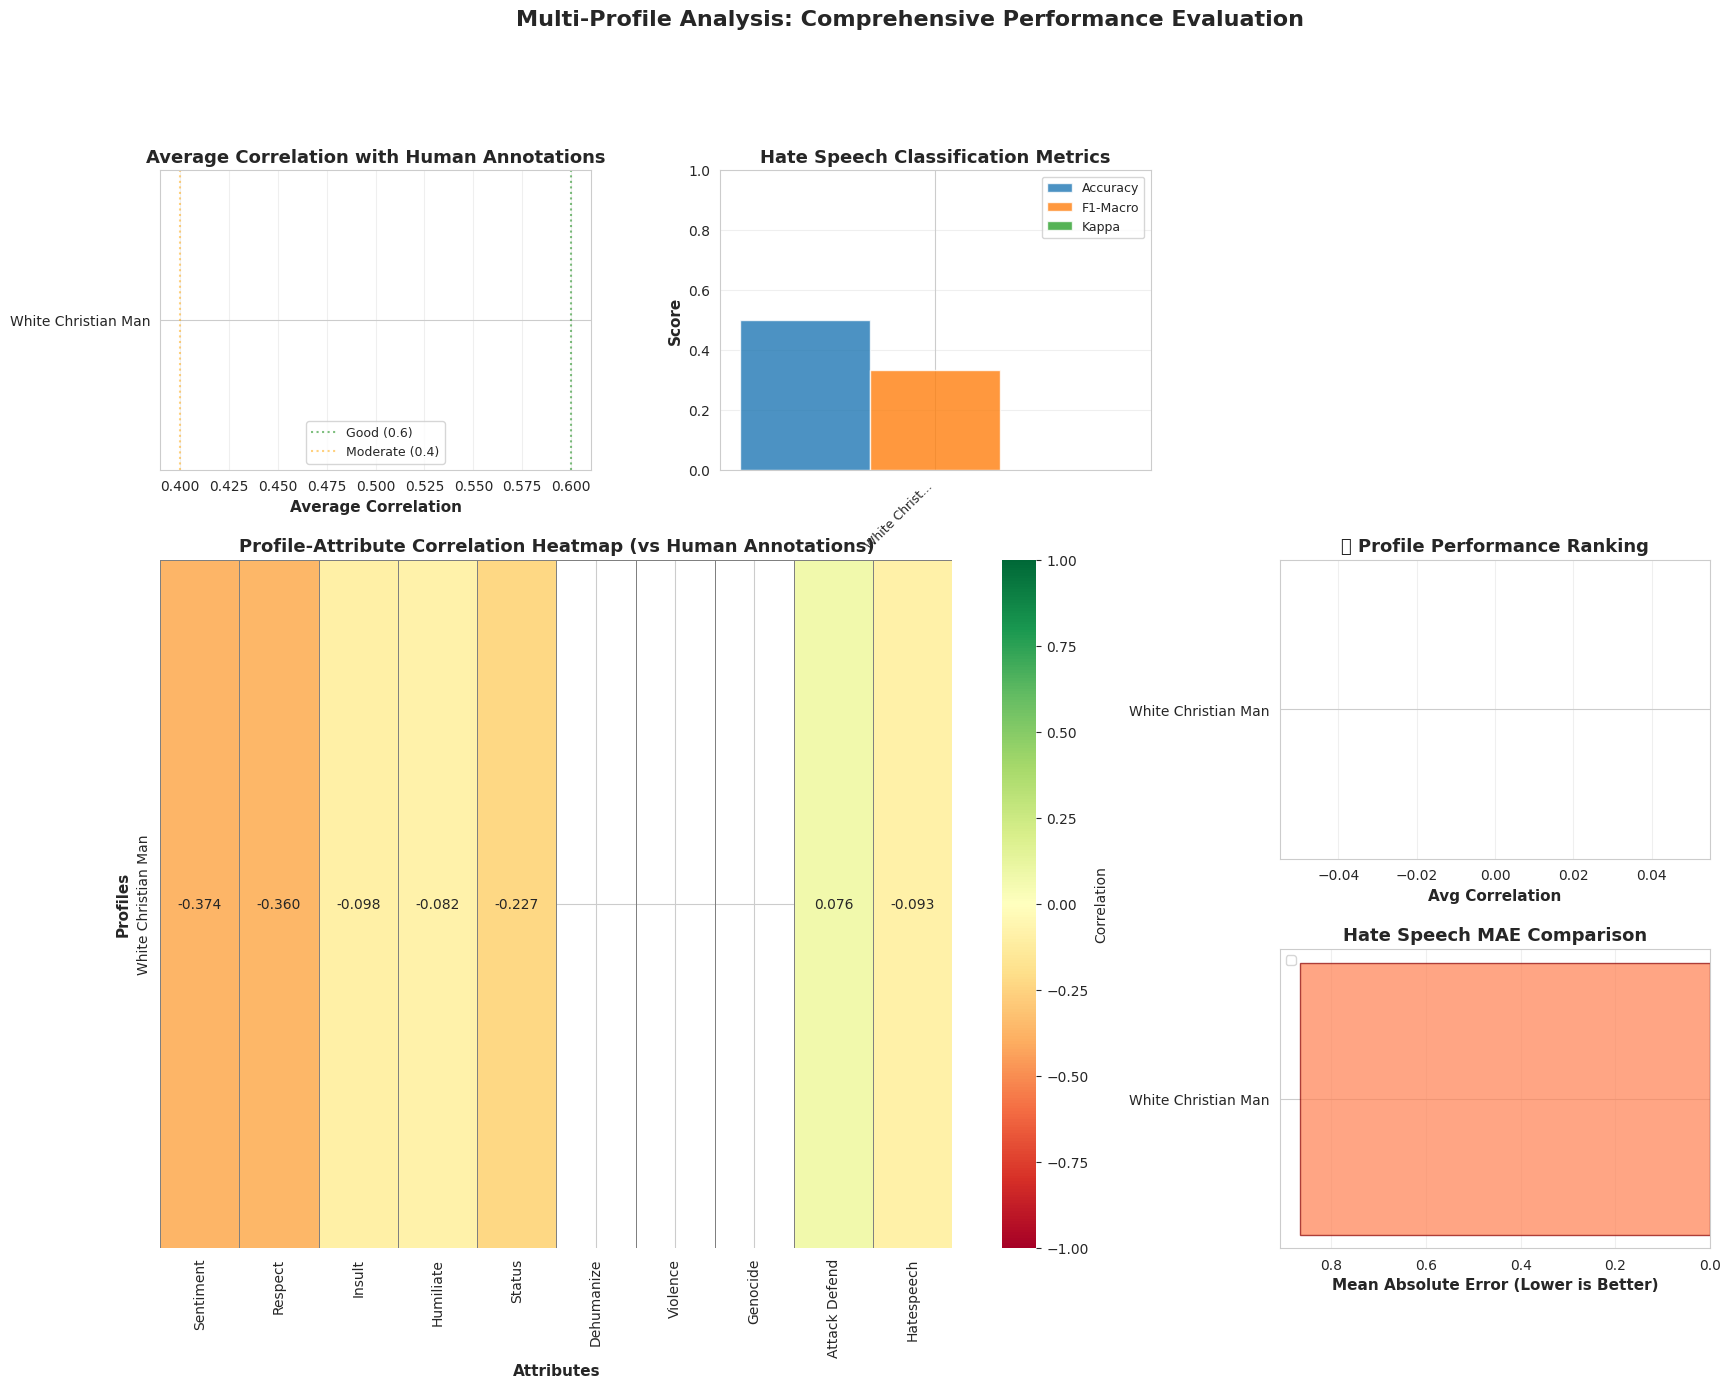


📊 Visualization complete!


In [ ]:
# Create Comprehensive Visualization Comparing All Profiles vs Vanilla
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Creating comprehensive comparison visualizations...")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Average Correlation Comparison (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
profiles = [p.replace('_', ' ').title() for p in profile_metrics.keys()]
avg_corrs = [m['avg_correlation'] for m in profile_metrics.values()]

# Add vanilla baseline if available
if vanilla_metrics:
    vanilla_corrs = []
    for attr in all_attributes:
        if attr in vanilla_metrics and 'correlation' in vanilla_metrics[attr]:
            vanilla_corrs.append(vanilla_metrics[attr]['correlation'])
    if vanilla_corrs:
        vanilla_avg = np.mean(vanilla_corrs)
        ax1.axhline(y=vanilla_avg, color='red', linestyle='--', linewidth=2,
                    label=f'Vanilla Baseline ({vanilla_avg:.3f})', alpha=0.7)

bars = ax1.barh(profiles, avg_corrs, color='skyblue', alpha=0.8, edgecolor='navy')
ax1.set_xlabel('Average Correlation', fontweight='bold', fontsize=11)
ax1.set_title('Average Correlation with Human Annotations', fontweight='bold', fontsize=13)
ax1.axvline(x=0.6, color='green', linestyle=':', alpha=0.5, label='Good (0.6)')
ax1.axvline(x=0.4, color='orange', linestyle=':', alpha=0.5, label='Moderate (0.4)')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Color bars based on performance
for i, (bar, corr) in enumerate(zip(bars, avg_corrs)):
    if corr >= 0.6:
        bar.set_color('green')
    elif corr >= 0.4:
        bar.set_color('orange')
    else:
        bar.set_color('red')
    bar.set_alpha(0.7)

# 2. Hate Speech Metrics Comparison (Top Middle)
ax2 = fig.add_subplot(gs[0, 1])
metrics_names = ['Accuracy', 'F1-Macro', 'Kappa']
x = np.arange(len(profiles))
width = 0.25

for i, metric_key in enumerate(['accuracy', 'f1_macro', 'kappa']):
    values = [profile_metrics[p]['classification'].get(metric_key, 0)
              if profile_metrics[p]['classification'] else 0
              for p in profile_metrics.keys()]
    ax2.bar(x + i*width, values, width, label=metrics_names[i], alpha=0.8)

# Add vanilla baseline
if vanilla_metrics and 'hatespeech' in vanilla_metrics:
    vanilla_vals = [
        vanilla_metrics['hatespeech'].get('accuracy', 0),
        vanilla_metrics['hatespeech'].get('f1_macro', 0),
        0  # Kappa not in vanilla
    ]
    for i, val in enumerate(vanilla_vals[:2]):  # Only accuracy and F1
        ax2.axhline(y=val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)

ax2.set_ylabel('Score', fontweight='bold', fontsize=11)
ax2.set_title('Hate Speech Classification Metrics', fontweight='bold', fontsize=13)
ax2.set_xticks(x + width)
ax2.set_xticklabels([p[:12] + '...' if len(p) > 12 else p for p in profiles],
                     rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# 3. Improvement Over Vanilla (Top Right)
if vanilla_metrics:
    ax3 = fig.add_subplot(gs[0, 2])

    improvements = []
    for profile_name in profile_metrics.keys():
        profile_avg = profile_metrics[profile_name]['avg_correlation']
        vanilla_corrs = []
        for attr in all_attributes:
            if attr in vanilla_metrics and 'correlation' in vanilla_metrics[attr]:
                vanilla_corrs.append(vanilla_metrics[attr]['correlation'])
        vanilla_avg = np.mean(vanilla_corrs) if vanilla_corrs else 0
        improvements.append(profile_avg - vanilla_avg)

    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars3 = ax3.barh(profiles, improvements, color=colors, alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='black', linewidth=2)
    ax3.set_xlabel('Improvement vs Vanilla', fontweight='bold', fontsize=11)
    ax3.set_title('Correlation Improvement Over Vanilla Baseline', fontweight='bold', fontsize=13)
    ax3.grid(axis='x', alpha=0.3)

    # Add value labels
    for bar, imp in zip(bars3, improvements):
        width = bar.get_width()
        ax3.text(width, bar.get_y() + bar.get_height()/2,
                f'{imp:+.3f}', ha='left' if width > 0 else 'right',
                va='center', fontsize=9, fontweight='bold')

# 4. Attribute-Level Correlations Heatmap (Bottom Left - Spans 2 columns)
ax4 = fig.add_subplot(gs[1:, :2])

# Build correlation matrix
corr_matrix = []
for profile_name in profile_metrics.keys():
    corrs = []
    for attr in all_attributes:
        corrs.append(profile_metrics[profile_name]['correlations'].get(attr, 0))
    corr_matrix.append(corrs)

corr_df = pd.DataFrame(corr_matrix,
                       index=[p.replace('_', ' ').title() for p in profile_metrics.keys()],
                       columns=[a.replace('_', ' ').title() for a in all_attributes])

sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax4, cbar_kws={'label': 'Correlation'},
            linewidths=0.5, linecolor='gray')
ax4.set_title('Profile-Attribute Correlation Heatmap (vs Human Annotations)',
              fontweight='bold', fontsize=13)
ax4.set_xlabel('Attributes', fontweight='bold', fontsize=11)
ax4.set_ylabel('Profiles', fontweight='bold', fontsize=11)

# 5. Profile Ranking (Bottom Right)
ax5 = fig.add_subplot(gs[1, 2])

rankings = [p[1]['avg_correlation'] for p in sorted_profiles]
profile_names_ranked = [p[0].replace('_', ' ').title() for p in sorted_profiles]

colors_ranked = ['gold' if i == 0 else 'silver' if i == 1 else 'brown' if i == 2 else 'lightblue'
                 for i in range(len(rankings))]

ax5.barh(profile_names_ranked, rankings, color=colors_ranked, alpha=0.8, edgecolor='black')
ax5.set_xlabel('Avg Correlation', fontweight='bold', fontsize=11)
ax5.set_title('🏆 Profile Performance Ranking', fontweight='bold', fontsize=13)
ax5.grid(axis='x', alpha=0.3)

# Add rank medals
for i, (name, score) in enumerate(zip(profile_names_ranked, rankings)):
    emoji = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else ""
    ax5.text(score + 0.01, i, f'{emoji} {score:.3f}', va='center', fontsize=10, fontweight='bold')

# 6. MAE Comparison (Bottom Right - Second)
ax6 = fig.add_subplot(gs[2, 2])

if all(profile_metrics[p]['classification'] for p in profile_metrics.keys()):
    mae_values = [profile_metrics[p]['classification'].get('mae', 0)
                  if profile_metrics[p]['classification'] else 0
                  for p in profile_metrics.keys()]

    bars6 = ax6.barh(profiles, mae_values, color='coral', alpha=0.7, edgecolor='darkred')

    # Add vanilla baseline
    if vanilla_metrics and 'hatespeech' in vanilla_metrics:
        vanilla_mae = vanilla_metrics['hatespeech'].get('mae', 0)
        ax6.axvline(x=vanilla_mae, color='red', linestyle='--', linewidth=2,
                    label=f'Vanilla MAE ({vanilla_mae:.3f})', alpha=0.7)

    ax6.set_xlabel('Mean Absolute Error (Lower is Better)', fontweight='bold', fontsize=11)
    ax6.set_title('Hate Speech MAE Comparison', fontweight='bold', fontsize=13)
    ax6.legend(fontsize=9)
    ax6.grid(axis='x', alpha=0.3)
    ax6.invert_xaxis()  # Invert so lower MAE is on the right

plt.suptitle('Multi-Profile Analysis: Comprehensive Performance Evaluation',
             fontsize=16, fontweight='bold', y=0.995)

# Save the figure
plot_filename = f"multiprofile_comprehensive_evaluation_{timestamp}.png"
plot_path = os.path.join(output_dir, plot_filename)
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved to: {plot_path}")

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete!")